In [165]:
import numpy as np
from scipy.special import softmax
import pandas as pd
import seaborn as sns
import pylab as pl
from scipy.optimize import minimize, differential_evolution
import belief_mix_model as bmm
import belief_mix_model_reward_comparison as bmm_spat
from scipy.spatial.distance import cdist,pdist,euclidean
from collections import Counter
import scipy as sp
import matplotlib.cm as cm
from matplotlib.patches import Ellipse
import scipy.stats as sp_st
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D      


In [2]:
data_dir = "../Lucas_Cecile/"
fig_dir = "./figures/brinkman_board/"

In [3]:
processed_data = pd.read_csv(data_dir+"extracted_trajs.csv")
random_agent = pd.read_csv(data_dir+"random_agent.csv")

all_data = pd.concat([processed_data, random_agent])

In [20]:
k_per_model=dict({'A':8,'B':9,'C':9})
marker_model = dict({'A':'p','B':'D','C':'o'})

In [5]:
model_fittings = pd.read_csv(data_dir+"fittings_reward_models_A_B_C.csv")
model_fittings['BIC'] = [ k_per_model[m]*np.log(n)+2*nll  for n,nll,m in zip(model_fittings.nchoices.values, model_fittings.NLL.values,model_fittings.Model.values)]
model_fittings

,Model,Subject,Phase,Species,NLL,NLL_per_choice,Random_NLL_per_choice,nchoices,success,W(row_scan),W(column_scan),W(spiral_scan),W(spatial_bias),W(reward),W(memory),memory_recall,beta,reward_decay,W(reward_availability),BIC
0,A,Amidala,Habituation,Macaca_mulatta,229.007261,2.410603,3.218876,95,True,0.331072,0.327906,0.341022,5.361216,5.000798,9.467403,0.906126,3.986949,NaN,NaN,494.445537
1,A,Amidala,Post-test,Macaca_mulatta,198.415715,2.088586,3.218876,95,True,0.438479,0.432015,0.129506,3.732950,2.290798,10.000000,0.933732,6.914395,NaN,NaN,433.262445
2,A,Amidala,Test,Macaca_mulatta,429.885625,2.262556,3.218876,190,True,0.271542,0.351006,0.377452,9.292446,0.010000,5.281833,0.604395,3.470659,NaN,NaN,901.747443
3,A,Anyanka,Habituation,Macaca_mulatta,193.121916,2.032862,3.218876,95,True,0.370719,0.303076,0.326205,1.395360,0.305600,10.000000,0.978855,20.000000,NaN,NaN,422.674848
4,A,Anyanka,Post-test,Macaca_mulatta,195.682520,2.059816,3.218876,95,True,0.460905,0.430603,0.108492,2.723395,0.728422,8.479681,0.904042,10.149629,NaN,NaN,427.796055
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,C,Yannick,Post-test,Macaca_tonkeana,163.600424,1.722110,3.218876,95,True,0.348965,0.434273,0.216761,7.132550,9.083373,7.570734,0.447021,4.193911,NaN,4.879606,368.185739
167,C,Yannick,Test,Macaca_tonkeana,403.349927,2.122894,3.218876,190,True,0.328987,0.417689,0.253324,7.193328,1.508492,2.452791,0.200000,4.619792,NaN,0.344127,853.923071
168,C,Yin,Habituation,Macaca_tonkeana,240.707756,2.533766,3.218876,95,True,0.239171,0.163626,0.597203,1.036899,0.720049,10.000000,0.432893,20.000000,NaN,0.094219,522.400404
169,C,Yin,Post-test,Macaca_tonkeana,172.379712,2.268154,3.218876,76,True,0.315738,0.182159,0.502103,1.179300,1.919792,10.000000,0.274210,20.000000,NaN,0.179423,383.736024


In [159]:
recovery_df = pd.read_csv(data_dir+"recovery_reward_models_A_B.csv")
recovery_df

,Model,Subject,Phase,Species,iter,LL,W(row_scan),W(row_scan) - sim,W(column_scan),W(column_scan) - sim,...,W(memory),W(memory) - sim,memory_recall,memory_recall - sim,beta,beta - sim,reward_decay,reward_decay - sim,W(reward_availability),W(reward_availability) - sim
0,A,Amidala,Habituation,Macaca_mulatta,0,220.148932,0.331072,0.387061,0.327906,0.269263,...,9.467403,7.852983,0.906126,0.877225,3.986949,4.970189,NaN,NaN,NaN,NaN
1,A,Amidala,Habituation,Macaca_mulatta,1,216.531830,0.331072,0.355815,0.327906,0.353873,...,9.467403,7.264079,0.906126,0.886366,3.986949,5.608110,NaN,NaN,NaN,NaN
2,A,Amidala,Habituation,Macaca_mulatta,2,232.586001,0.331072,0.266246,0.327906,0.370155,...,9.467403,5.374667,0.906126,0.891233,3.986949,5.163151,NaN,NaN,NaN,NaN
3,A,Amidala,Habituation,Macaca_mulatta,3,240.953799,0.331072,0.293547,0.327906,0.305310,...,9.467403,8.428566,0.906126,0.894115,3.986949,4.937546,NaN,NaN,NaN,NaN
4,A,Amidala,Habituation,Macaca_mulatta,4,219.090081,0.331072,0.303767,0.327906,0.269853,...,9.467403,5.423607,0.906126,0.865391,3.986949,5.278187,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1065,C,Iron,Post-test,Macaca_tonkeana,5,190.921276,0.218856,0.252947,0.102413,0.224848,...,3.680291,9.478486,0.200000,0.200000,2.409496,10.531141,NaN,NaN,1.014433,0.229631
1066,C,Iron,Post-test,Macaca_tonkeana,6,177.917928,0.218856,0.261084,0.102413,0.154877,...,3.680291,8.108375,0.200000,0.200000,2.409496,7.119504,NaN,NaN,1.014433,0.560396
1067,C,Iron,Post-test,Macaca_tonkeana,7,179.459161,0.218856,0.319930,0.102413,0.001938,...,3.680291,10.000000,0.200000,0.818788,2.409496,20.000000,NaN,NaN,1.014433,0.010045
1068,C,Iron,Post-test,Macaca_tonkeana,8,172.178350,0.218856,0.223620,0.102413,0.178097,...,3.680291,4.510416,0.200000,0.200000,2.409496,2.732557,NaN,NaN,1.014433,0.880818


In [97]:
model_fittings = model_fittings.loc[model_fittings['Model']!='C']

In [160]:
recovery_df = recovery_df.loc[recovery_df['Model']!='C']

In [127]:
phase_order = ['Habituation', 'Test','Post-test']
cmap1 = 'Accent'
cmap2 = 'tab10'
cmap3 = 'prism'
colors = [cm.get_cmap('prism',2)(0),cm.get_cmap('prism',2)(1)]
cmap4 = dict({'data':'cornflowerblue','model - A':colors[0], 'model - B':colors[1]})

/tmp/ipykernel_1325553/630910657.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [cm.get_cmap('prism',2)(0),cm.get_cmap('prism',2)(1)]


In [122]:
def plot_boxplots_with_points(x_var,y_var,col_var,hue_var,order,palette,data,col_wrap,dodge=False,sharey=True):
   
    g1 = sns.catplot(x=x_var,y=y_var,col=col_var,data=data,kind='box',hue=hue_var,col_wrap=col_wrap,palette=palette,order=order,fill=False,dodge=dodge,sharey=sharey)
    for ax in g1.axes:
        for x in ax.get_xticklabels():
            x.set_rotation(45)
            x.set_ha('right')
        ax.set_xlabel("")
        tit = ax.get_title().split(' = ')[1]
        sub = data.loc[data[col_var]==tit].copy()
        sns.stripplot(ax=ax,data=sub,x=x_var,y=y_var,hue=hue_var,palette=palette,order=order,dodge=dodge,legend=False,s=6)
        ax.set_xlabel("")
    g1.figure.subplots_adjust(bottom=0.2)

    return g1

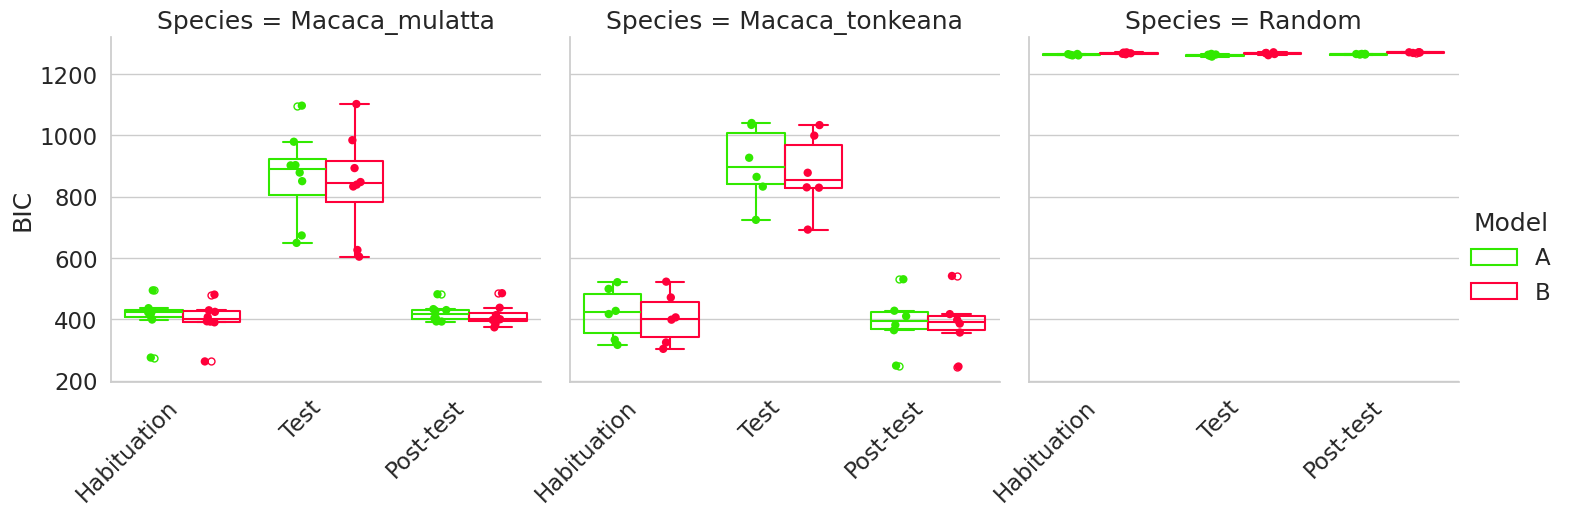

In [123]:
g1 = plot_boxplots_with_points("Phase","BIC","Species","Model",phase_order,cmap3,model_fittings,3,True)

# for ax in g1.axes:
#     xlims = ax.get_xlim()
#     ax.hlines(y=3.22,xmin=xlims[0],xmax=xlims[1],ls='dashed',color='k',lw=1.5)
#     ax.set_xlim(xlims[0],xlims[1])
g1.savefig(fig_dir+"BIC_with_respect_to_chance_level.png")

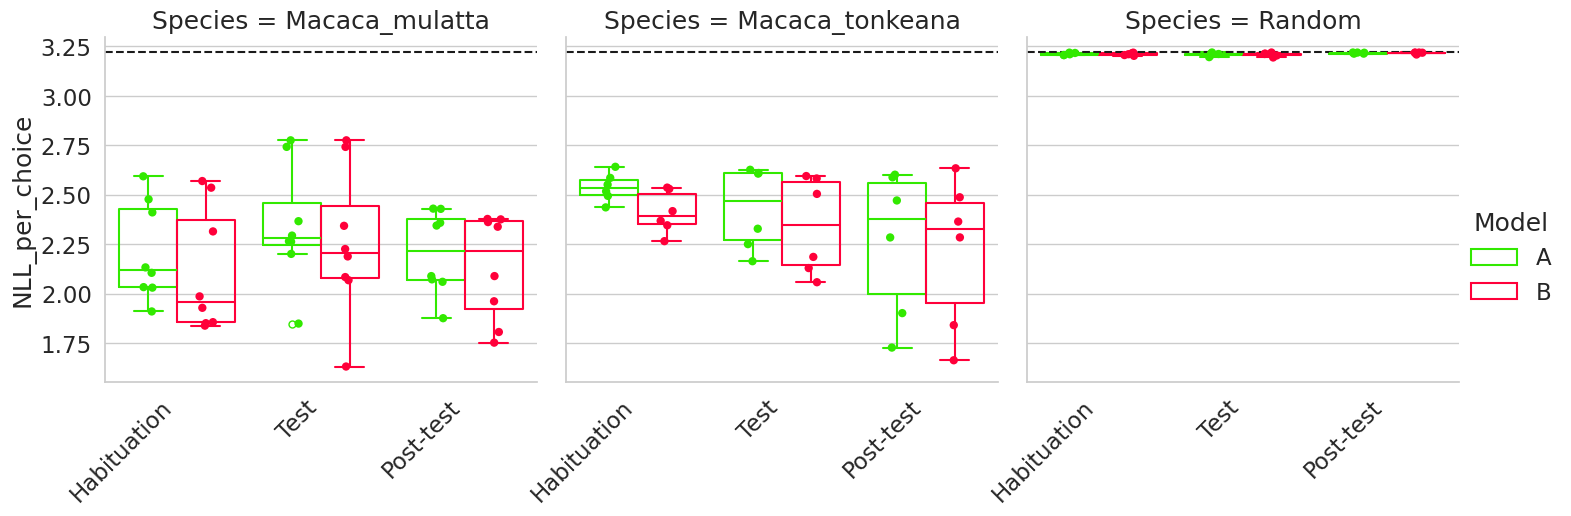

In [124]:
g1 = plot_boxplots_with_points("Phase","NLL_per_choice","Species","Model",phase_order,cmap3,model_fittings,3,True)

for ax in g1.axes:
    xlims = ax.get_xlim()
    ax.hlines(y=3.22,xmin=xlims[0],xmax=xlims[1],ls='dashed',color='k',lw=1.5)
    ax.set_xlim(xlims[0],xlims[1])
g1.savefig(fig_dir+"LL_with_respect_to_chance_level.png")

In [102]:
compare_trajs = pd.DataFrame()
compare_stats = pd.DataFrame()
compare_dist_trajs = pd.DataFrame()
compare_visit_map = pd.DataFrame()


for grp in model_fittings.groupby(['Model', 'Subject', 'Phase', 'Species']):

    model = grp[0][0]
    Subject = grp[0][1]
    Phase = grp[0][2]
    Species = grp[0][3]

    fit = grp[1].iloc[0]

    # ------------------------------------------------------------
    # Common fitted parameters
    # ------------------------------------------------------------

    wRS = fit['W(row_scan)']
    wCS = fit['W(column_scan)']
    wSS = fit['W(spiral_scan)']

    wK = fit['W(spatial_bias)']
    wR = fit['W(reward)']
    wM = fit['W(memory)']

    decay = fit['memory_recall']
    beta = fit['beta']

    # Model B only
    if model == 'B':
        reward_decay = fit['reward_decay']

    # Model C only
    if model == 'C':
        wA = fit['W(reward_availability)']


    # ------------------------------------------------------------
    # Get actual trajectories
    # ------------------------------------------------------------

    sim_trajs = []

    act_data = all_data.loc[
        (all_data['Subject'] == Subject) &
        (all_data['Phase'] == Phase) &
        (all_data['Species'] == Species)
    ].copy()

    act_trajs = [
        [[x, y] for x, y in zip(tr.Rows, tr.Cols)]
        for _, tr in act_data.groupby('Session')
    ]

    Nsim = len(act_trajs)


    # ------------------------------------------------------------
    # Statistics containers
    # ------------------------------------------------------------

    stats_act = {
        'revisit_rate': [],
        'traj_num': [],
        'jump_length': [],
        'first_revisit': [],
        'total_dist': []
    }

    stats_sim = {
        'revisit_rate': [],
        'traj_num': [],
        'jump_length': [],
        'first_revisit': [],
        'total_dist': []
    }


    dist_between_trajs = []
    corr_between_trajs = []
    trials = []


    # ------------------------------------------------------------
    # Simulate trajectory-by-trajectory
    # ------------------------------------------------------------

    for i, traj in enumerate(act_trajs):

        start = traj[0]

        # Common arguments
        sim_kwargs = dict(
            start_loc=start,
            T=len(traj) - 1,
            sigma=1.0,
            decay=decay,
            wK=wK,
            wR=wR,
            wM=wM,
            beta=beta,
            wRS=wRS,
            wCS=wCS,
            wSS=wSS,
            model=model
        )

        # Model B
        if model == 'B':
            sim_kwargs['reward_decay'] = reward_decay

        # Model C
        if model == 'C':
            sim_kwargs['wA'] = wA


        # New simulate_case()
        sim_result = bmm_spat.simulate_case(**sim_kwargs)

        # First returned object is always the trajectory
        sim = sim_result[0]

        sim_trajs.append(sim)
        trials.append([i] * len(traj))


        # --------------------------------------------------------
        # Behavioral statistics
        # --------------------------------------------------------

        revis_act = bmm_spat.revisit_rate(traj)
        first_rev_act = bmm_spat.first_revisit(traj)
        revis_sim = bmm_spat.revisit_rate(sim)
        first_rev_sim = bmm_spat.first_revisit(sim)

        mean_jump_act, var_jump_act, tot_jump_act = bmm_spat.jump_lengths(traj)

        mean_jump_sim, var_jump_sim, tot_jump_sim = bmm_spat.jump_lengths(sim)

        tot_dist_act = bmm_spat.calc_total_distance_covered(traj)
        tot_dist_sim = bmm_spat.calc_total_distance_covered(sim)


        # Actual
        stats_act['revisit_rate'].append(revis_act)
        stats_act['jump_length'].append(mean_jump_act)
        stats_act['first_revisit'].append(first_rev_act)
        stats_act['total_dist'].append(tot_dist_act)
        stats_act['traj_num'].append(i)

        # Model
        stats_sim['revisit_rate'].append(revis_sim)
        stats_sim['jump_length'].append(mean_jump_sim)
        stats_sim['first_revisit'].append(first_rev_sim)
        stats_sim['total_dist'].append(tot_dist_sim)
        stats_sim['traj_num'].append(i)


        # --------------------------------------------------------
        # Distance between actual and simulated trajectory
        # --------------------------------------------------------

        dist, corr = bmm_spat.calc_dist_bw_traj(traj, sim)

        dist_between_trajs.append(dist)
        corr_between_trajs.append(corr)


    # ------------------------------------------------------------
    # Visit maps
    # ------------------------------------------------------------

    Vobs = sum(
        bmm_spat.visit_map(t)
        for t in act_trajs
    )

    Vsim = sum(
        bmm_spat.visit_map(t)
        for t in sim_trajs
    )


    Vobs_df = pd.DataFrame(
        Vobs,
        columns=np.arange(1, 6),
        index=np.arange(1, 6)
    )

    Vobs_df['type'] = 'data'


    Vsim_df = pd.DataFrame(
        Vsim,
        columns=np.arange(1, 6),
        index=np.arange(1, 6)
    )

    Vsim_df['type'] = 'model - '+model


    Vmap = pd.concat([
        Vobs_df,
        Vsim_df
    ])

#     Vmap['Model'] = model
    Vmap['Subject'] = Subject
    Vmap['Phase'] = Phase
    Vmap['Species'] = Species


    compare_visit_map = pd.concat([
        compare_visit_map,
        Vmap
    ])


    # ------------------------------------------------------------
    # Behavioral statistics dataframe
    # ------------------------------------------------------------

    stats_act_df = pd.DataFrame(stats_act)
    stats_act_df['type'] = 'data'

    stats_sim_df = pd.DataFrame(stats_sim)
    stats_sim_df['type'] = 'model - '+model

    to_add = pd.concat([
        stats_act_df,
        stats_sim_df
    ])

#     to_add['Model'] = model
    to_add['Subject'] = Subject
    to_add['Phase'] = Phase
    to_add['Species'] = Species


    compare_stats = pd.concat([
        compare_stats,
        to_add
    ])


    # ------------------------------------------------------------
    # Distance between trajectories
    # ------------------------------------------------------------

    temp_df = pd.DataFrame()

    temp_df['dist_traj(model,data)'] = dist_between_trajs
    temp_df['corr_traj(model,data)'] = corr_between_trajs

    temp_df['Model'] = model
    temp_df['Subject'] = Subject
    temp_df['Phase'] = Phase
    temp_df['Species'] = Species


    compare_dist_trajs = pd.concat([
        compare_dist_trajs,
        temp_df
    ])


    # ------------------------------------------------------------
    # Actual vs simulated trajectories
    # ------------------------------------------------------------

    temp = pd.DataFrame()

    temp['Rows_model'] = np.array(sim_trajs)[:, :, 0].flatten()
    temp['Cols_model'] = np.array(sim_trajs)[:, :, 1].flatten()

    temp['Rows_data'] = np.array(act_trajs)[:, :, 0].flatten()
    temp['Cols_data'] = np.array(act_trajs)[:, :, 1].flatten()

    temp['Trials'] = np.hstack(trials)

    temp['Model'] = model
    temp['Subject'] = Subject
    temp['Phase'] = Phase
    temp['Species'] = Species


    compare_trajs = pd.concat([
        compare_trajs,
        temp
    ])


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

compare_stats.to_csv(
    data_dir + "compare_stats_" + "model_comparison" + ".csv",
    index=False
)

compare_trajs.to_csv(
    data_dir + "compare_trajs_" + "model_comparison" + ".csv",
    index=False
)

compare_dist_trajs.to_csv(
    data_dir + "compare_dist_between_trajs_" + "model_comparison" + ".csv",
    index=False
)

compare_visit_map.to_csv(
    data_dir + "compare_visit_map_" + "model_comparison" + ".csv",
    index=False
)

/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: R

/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: R

/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: R

/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: R

/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jyotika/Utils/envs/strasbourg_school/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: R

In [103]:
len(act_trajs[0])

20

In [104]:
len(sim_trajs[0])

20

In [105]:
Vobs

array([[ 1.,  3.,  2.,  5.,  2.],
       [ 3.,  6.,  5.,  8., 13.],
       [ 5.,  6.,  7., 10.,  7.],
       [ 9., 11., 10.,  9., 12.],
       [ 7., 14., 16., 15., 14.]])

In [106]:
Vsim

array([[ 6.,  5.,  8.,  5.,  0.],
       [ 9.,  9., 12.,  7.,  5.],
       [10., 11., 14.,  8.,  5.],
       [ 8., 12., 10., 12.,  6.],
       [ 6.,  7.,  9., 10.,  6.]])

In [107]:
compare_stats

,revisit_rate,traj_num,jump_length,first_revisit,total_dist,type,Subject,Phase,Species
0,0.00,0,1.631579,0,25.883627,data,Amidala,Habituation,Macaca_mulatta
1,0.10,1,1.894737,14,29.963990,data,Amidala,Habituation,Macaca_mulatta
2,0.05,2,2.000000,15,31.896819,data,Amidala,Habituation,Macaca_mulatta
3,0.10,3,2.105263,7,34.712101,data,Amidala,Habituation,Macaca_mulatta
4,0.05,4,1.947368,19,31.491901,data,Amidala,Habituation,Macaca_mulatta
...,...,...,...,...,...,...,...,...,...
5,0.20,5,1.947368,13,31.621579,model - B,Yin,Test,Macaca_tonkeana
6,0.15,6,2.105263,7,33.696384,model - B,Yin,Test,Macaca_tonkeana
7,0.25,7,2.052632,12,33.437875,model - B,Yin,Test,Macaca_tonkeana
8,0.30,8,2.736842,5,41.765266,model - B,Yin,Test,Macaca_tonkeana


In [108]:
stats_melt = compare_stats.melt(id_vars=['Subject','Species','Phase','type','traj_num'])

In [109]:
stats_melt

,Subject,Species,Phase,type,traj_num,variable,value
0,Amidala,Macaca_mulatta,Habituation,data,0,revisit_rate,0.000000
1,Amidala,Macaca_mulatta,Habituation,data,1,revisit_rate,0.100000
2,Amidala,Macaca_mulatta,Habituation,data,2,revisit_rate,0.050000
3,Amidala,Macaca_mulatta,Habituation,data,3,revisit_rate,0.100000
4,Amidala,Macaca_mulatta,Habituation,data,4,revisit_rate,0.050000
...,...,...,...,...,...,...,...
6427,Yin,Macaca_tonkeana,Test,model - B,5,total_dist,31.621579
6428,Yin,Macaca_tonkeana,Test,model - B,6,total_dist,33.696384
6429,Yin,Macaca_tonkeana,Test,model - B,7,total_dist,33.437875
6430,Yin,Macaca_tonkeana,Test,model - B,8,total_dist,41.765266


In [125]:
sns.set(style='whitegrid',font_scale=1.5)


<Figure size 640x480 with 0 Axes>

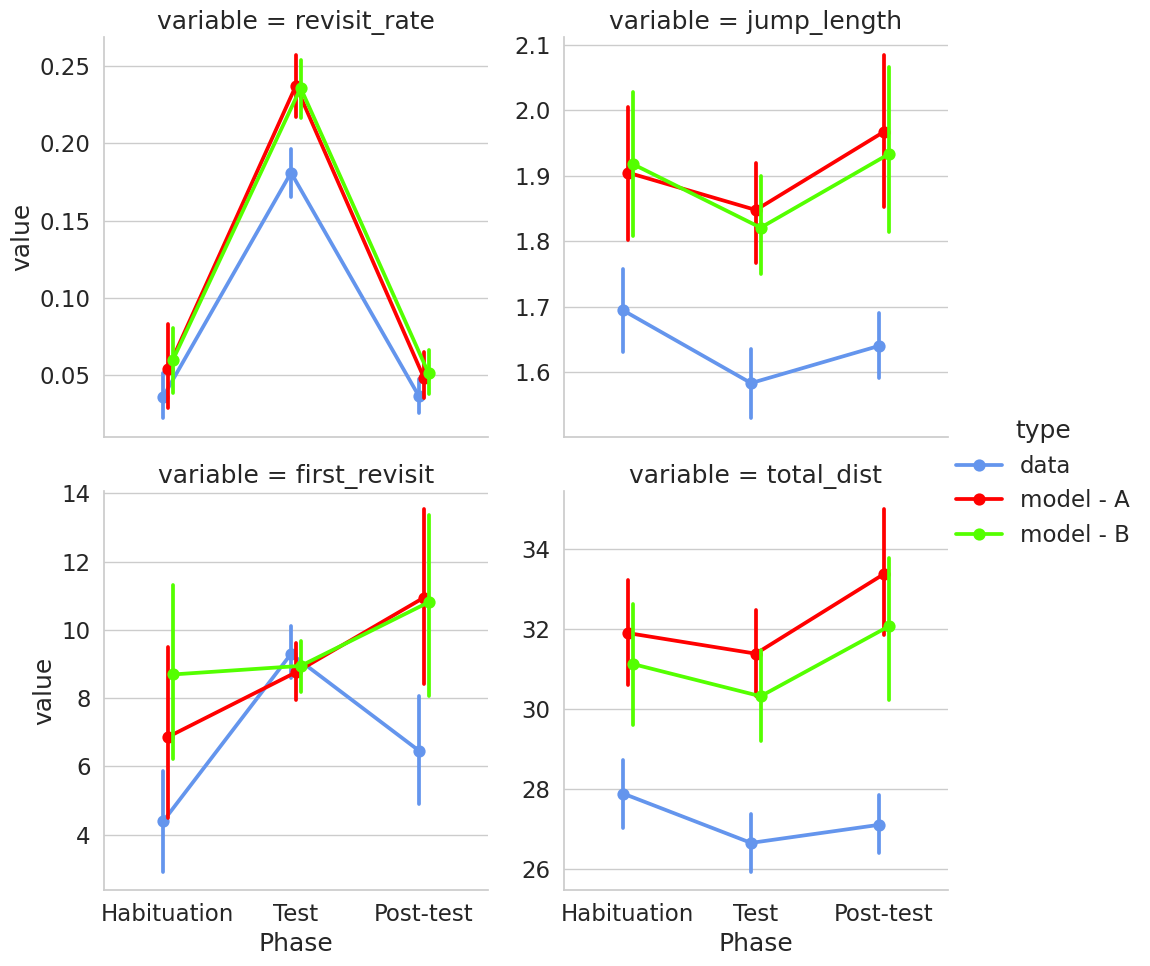

<Figure size 640x480 with 0 Axes>

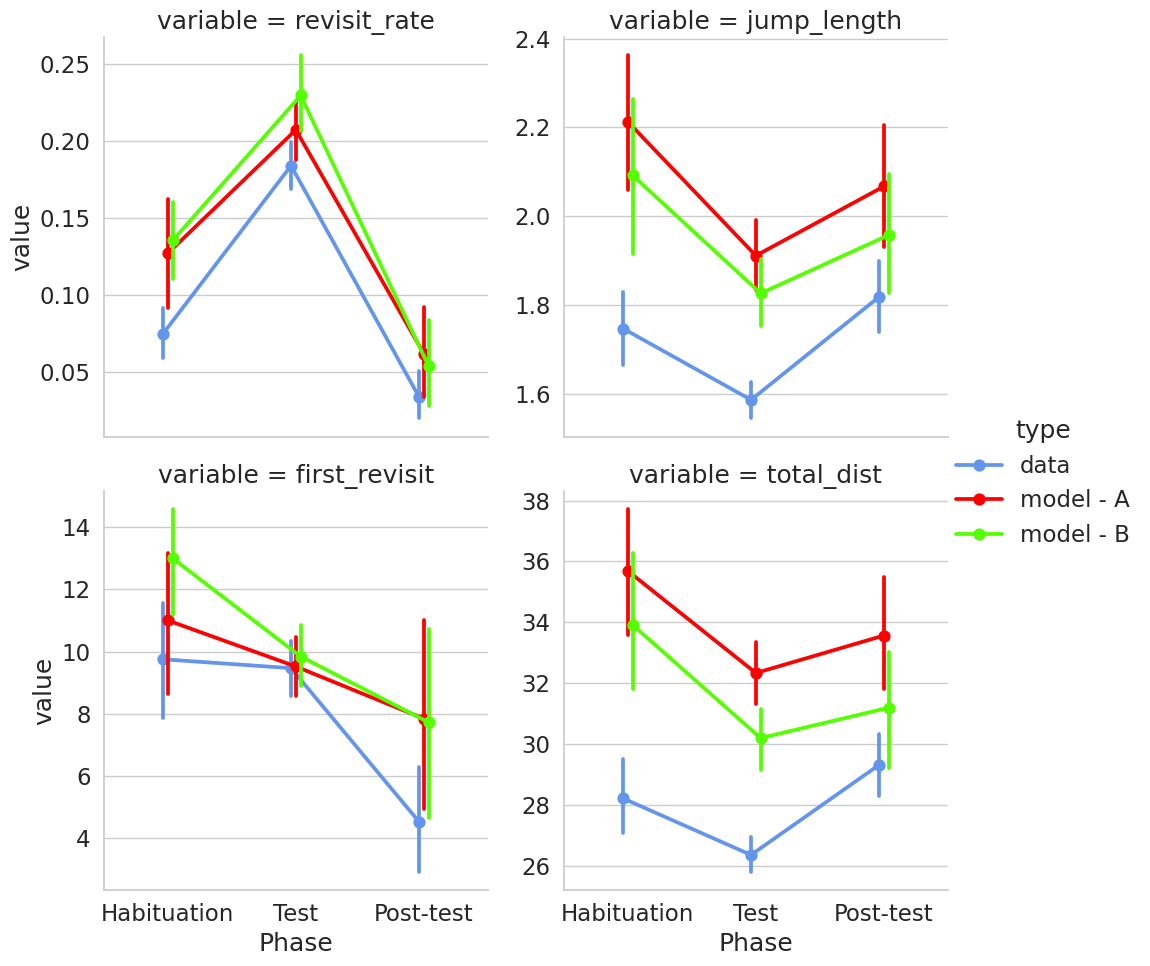

<Figure size 640x480 with 0 Axes>

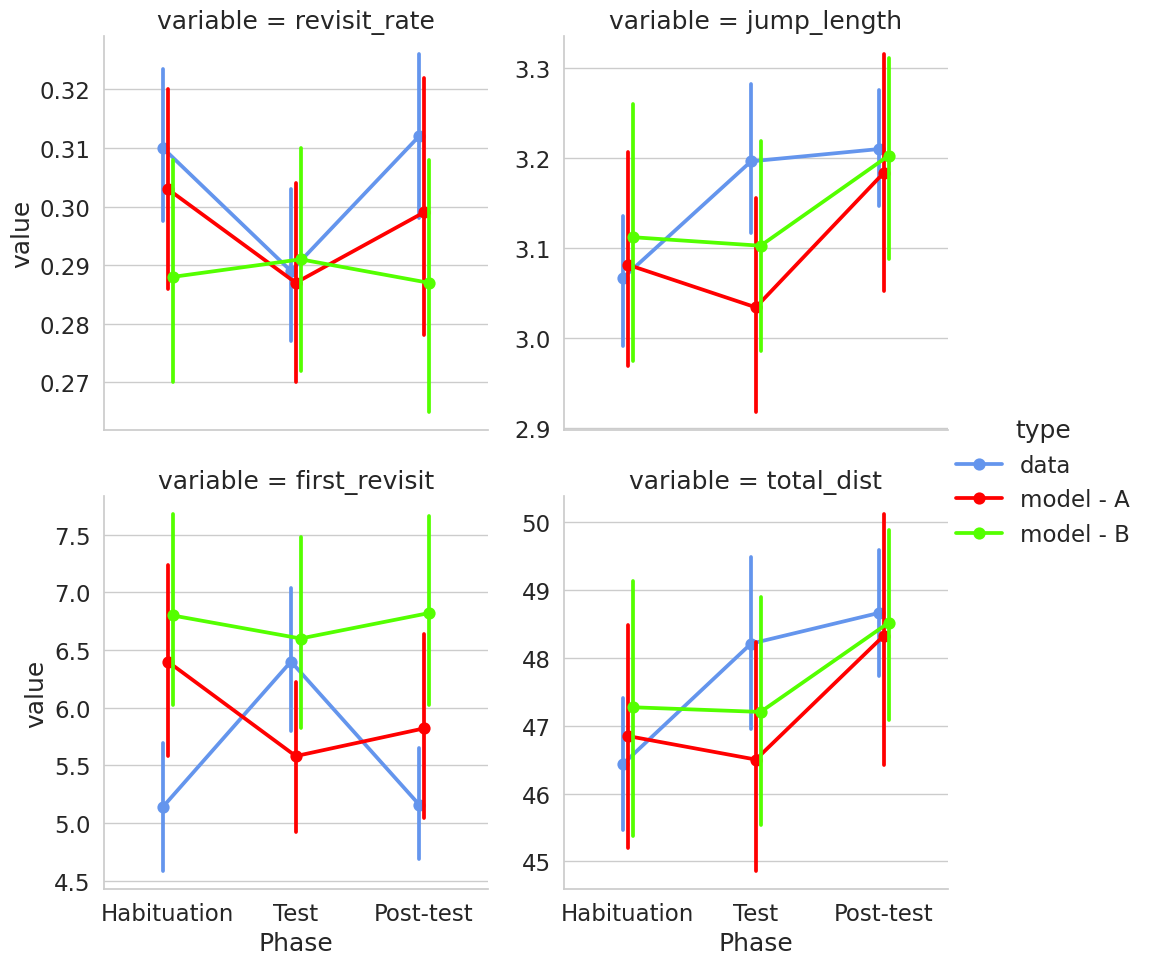

In [128]:
for grp in stats_melt.groupby('Species'):
    pl.figure()
    g1 = sns.catplot(x="Phase",y='value',hue='type',kind='point',col='variable',col_wrap=2,data=grp[1],palette=cmap4,sharey=False,order=phase_order,dodge=True)
    g1.savefig(fig_dir+"stats_compare_data_model_"+grp[0]+"_model_comparison_"+".png")

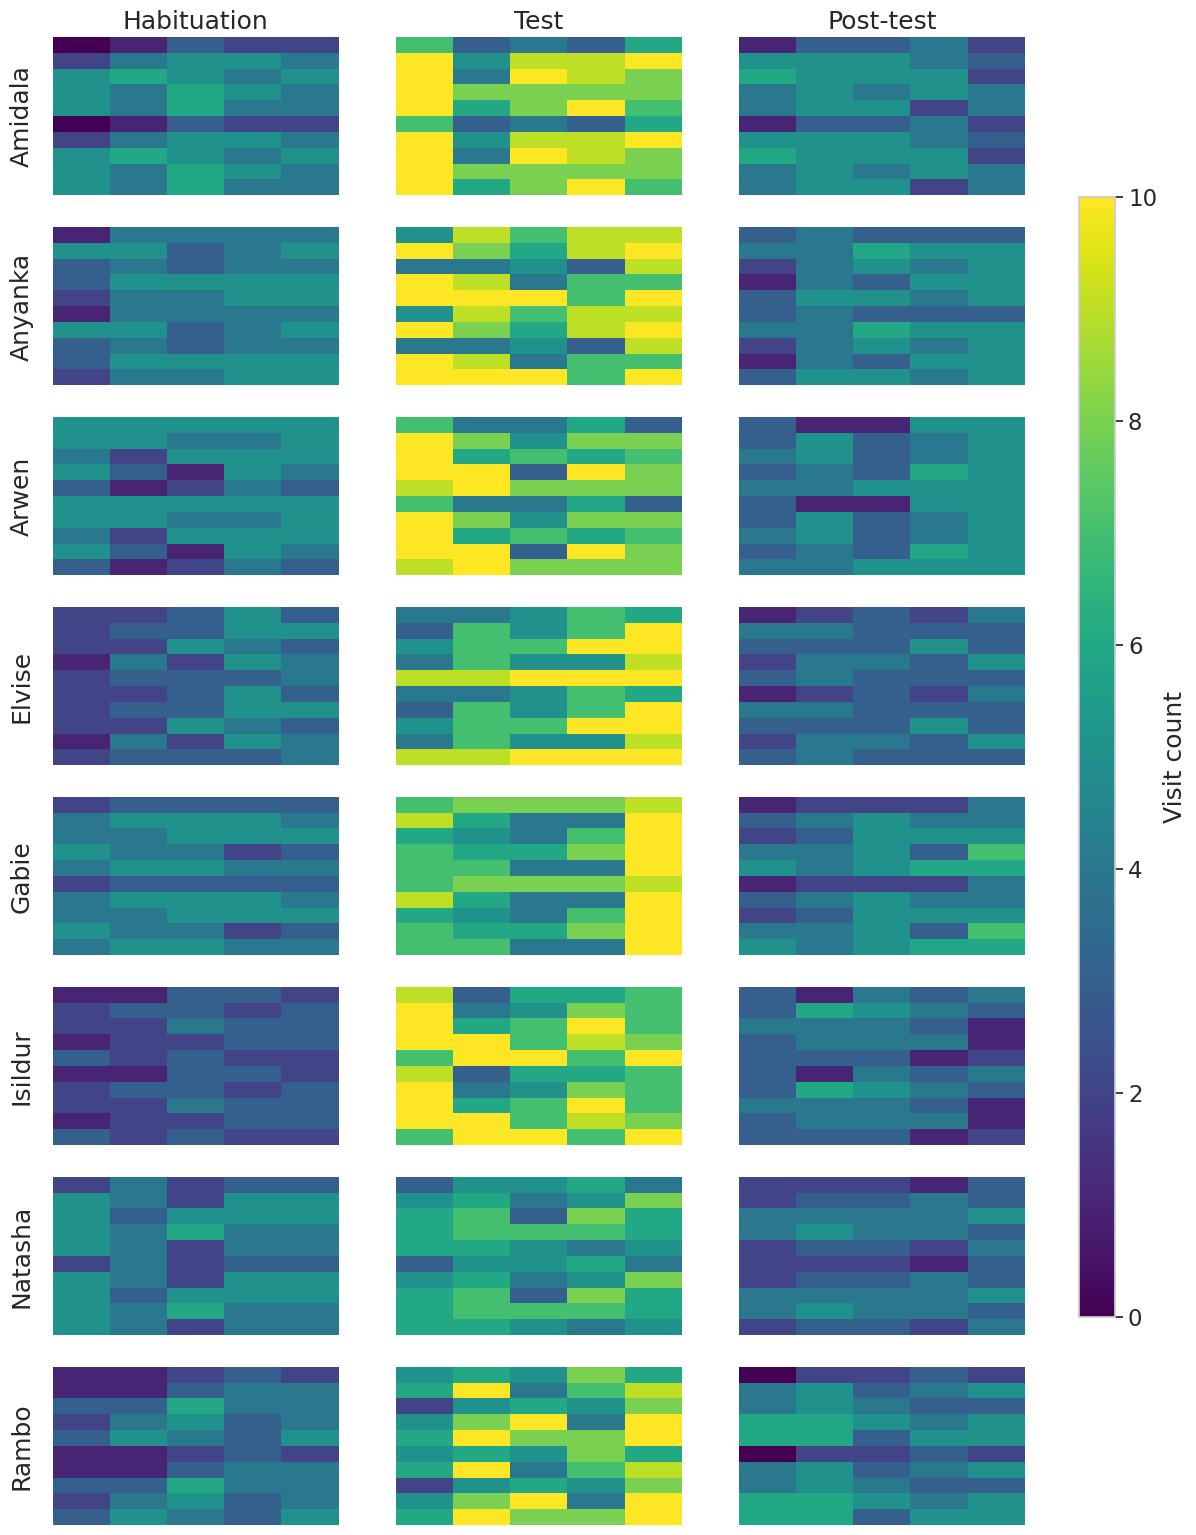

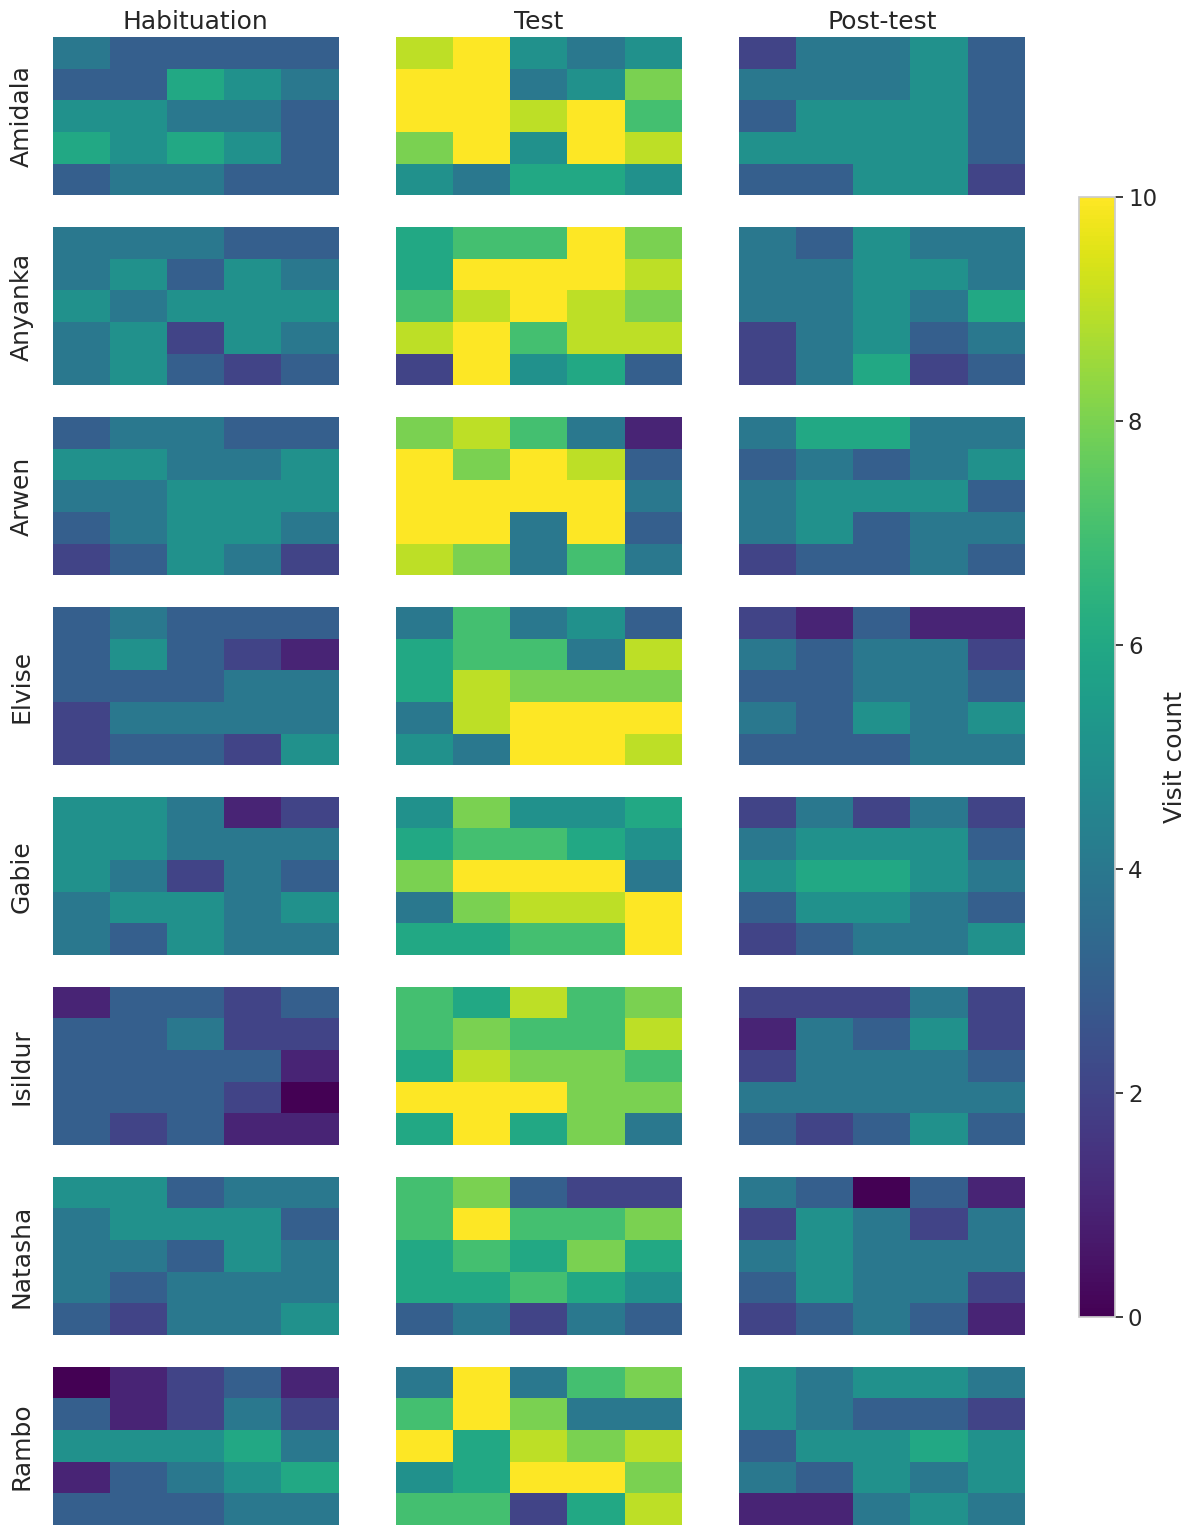

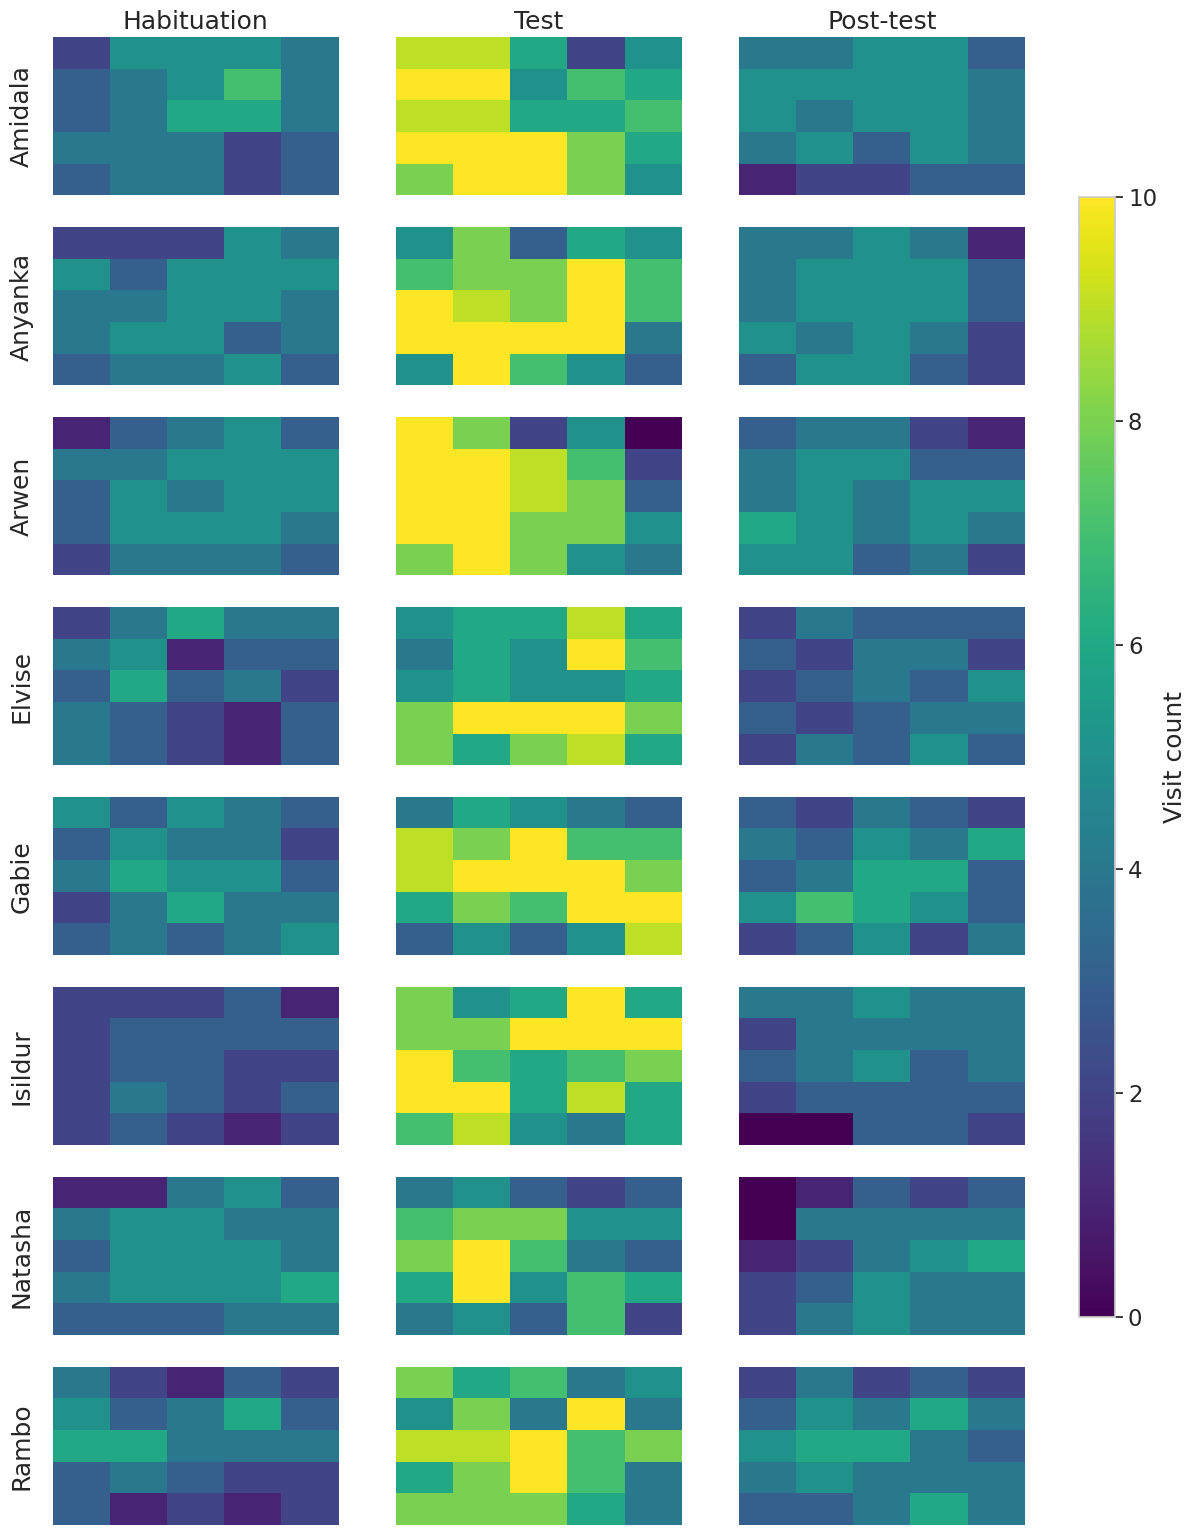

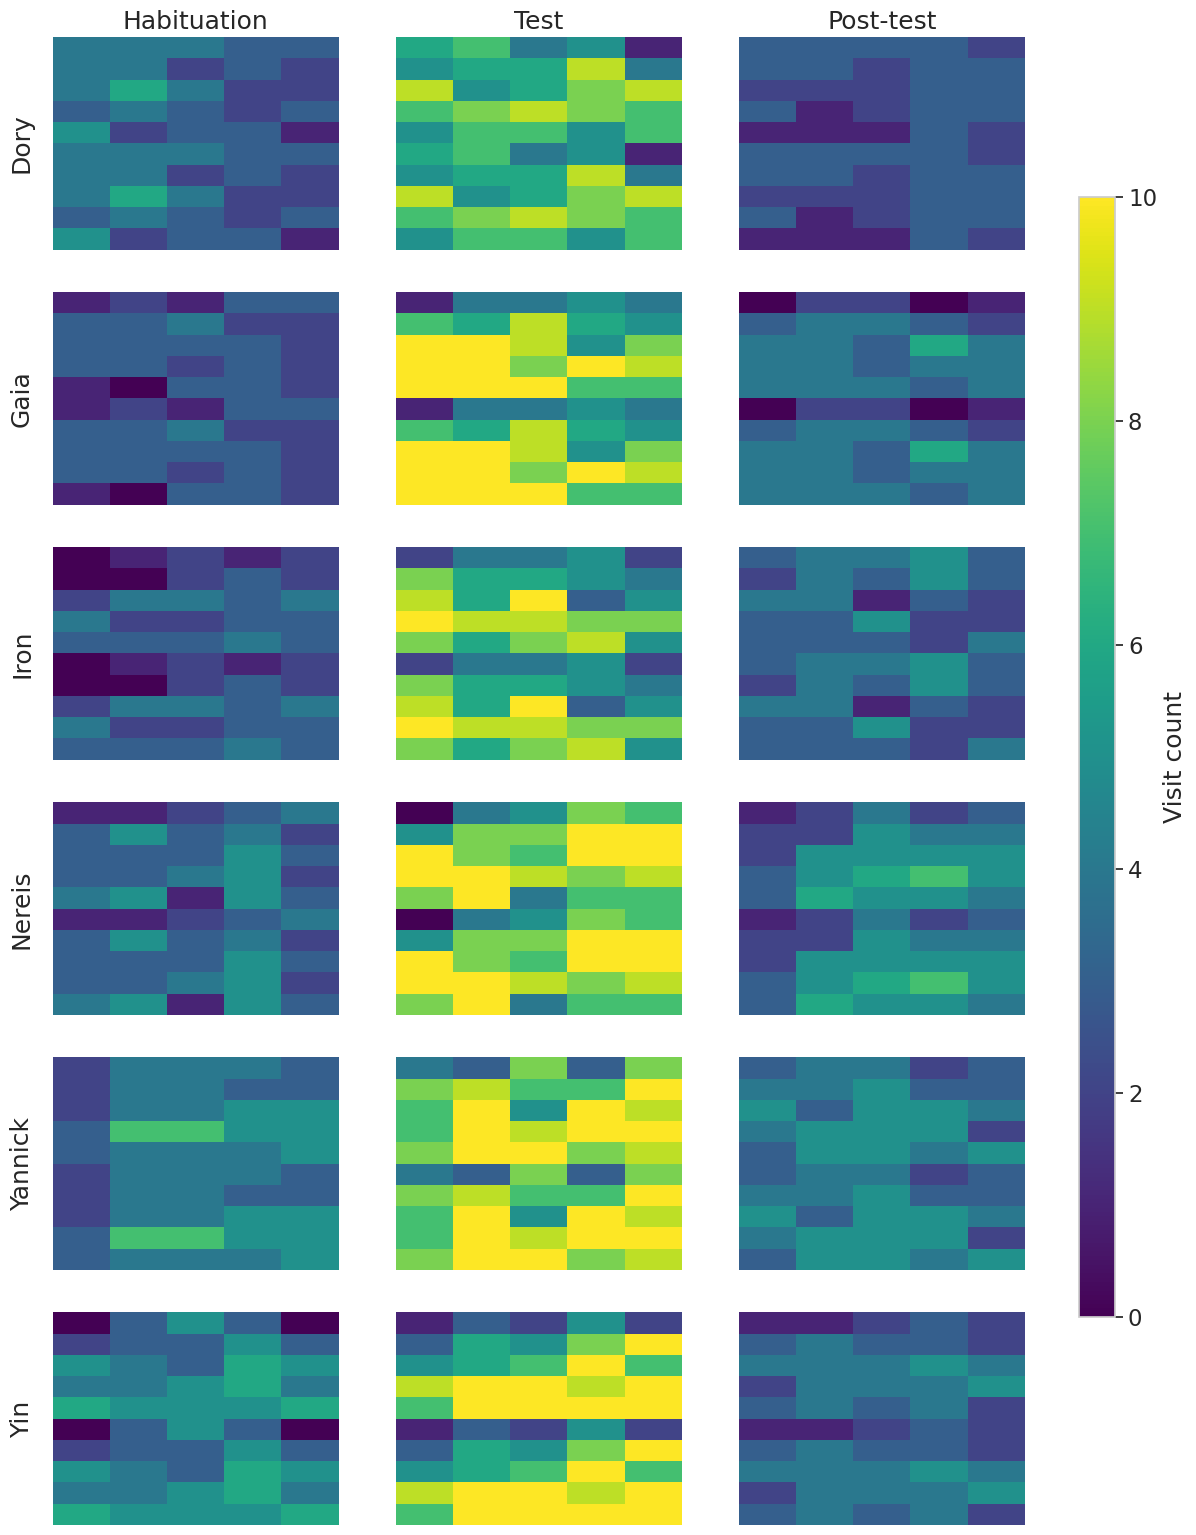

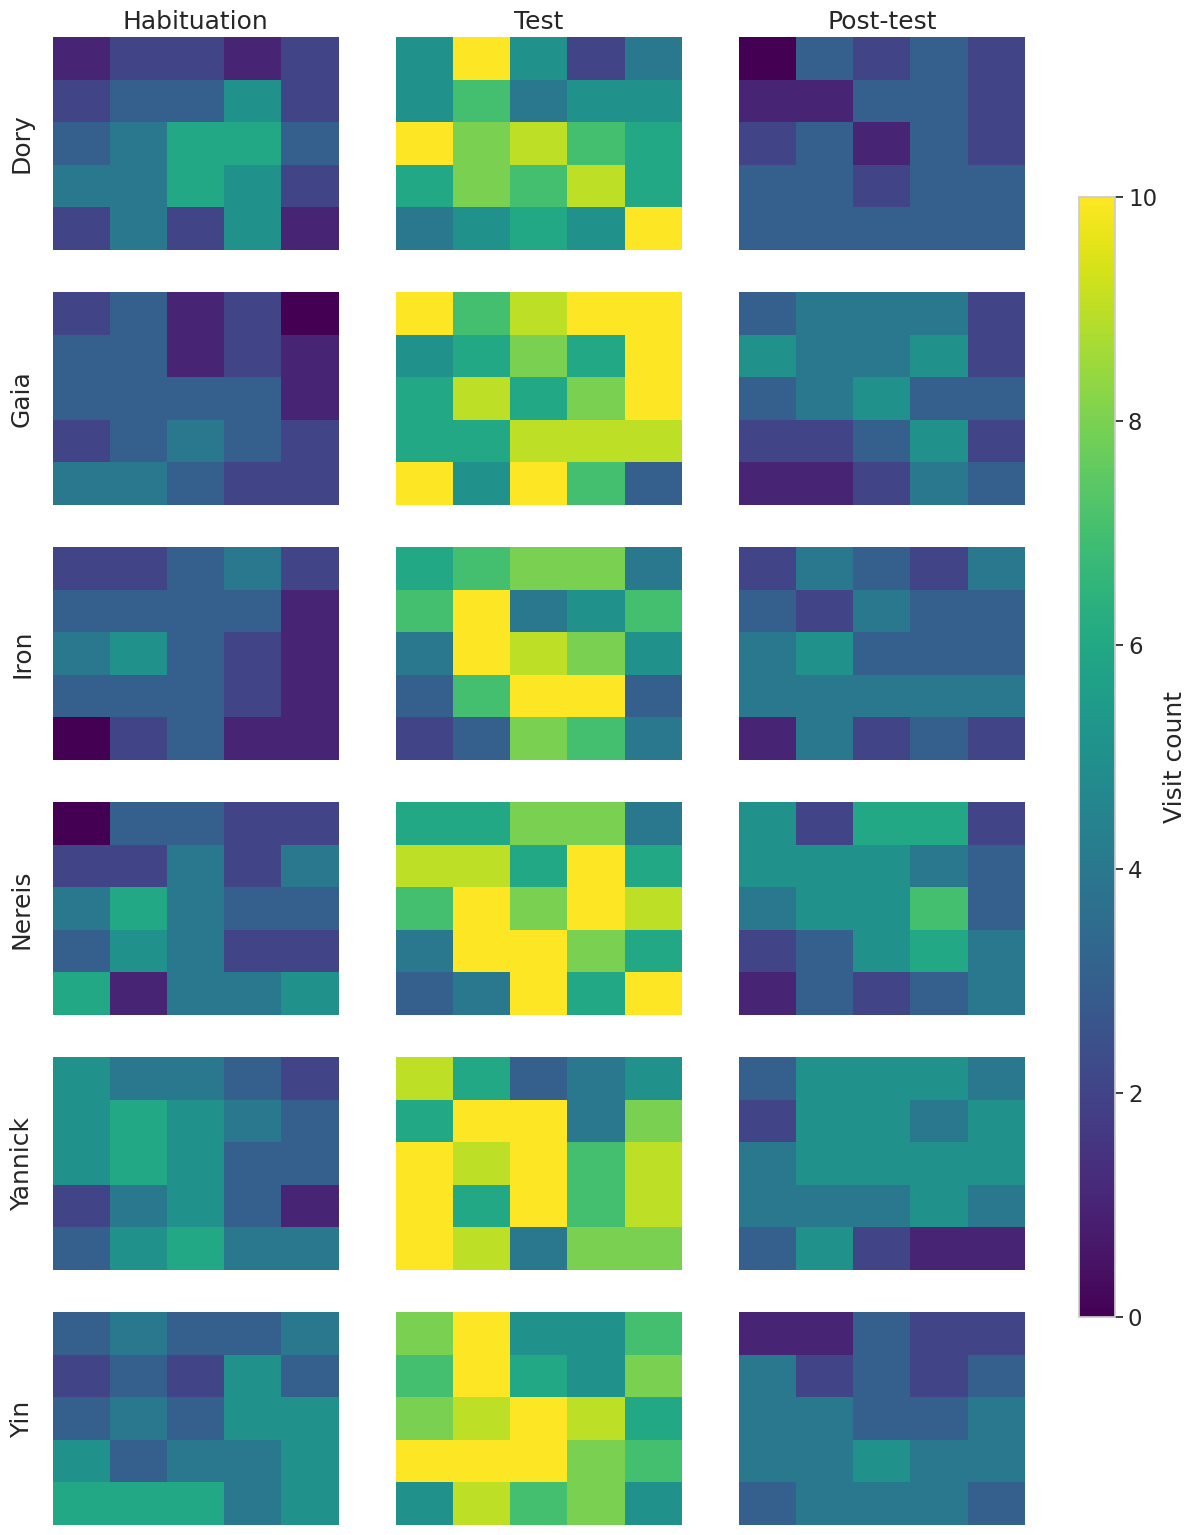

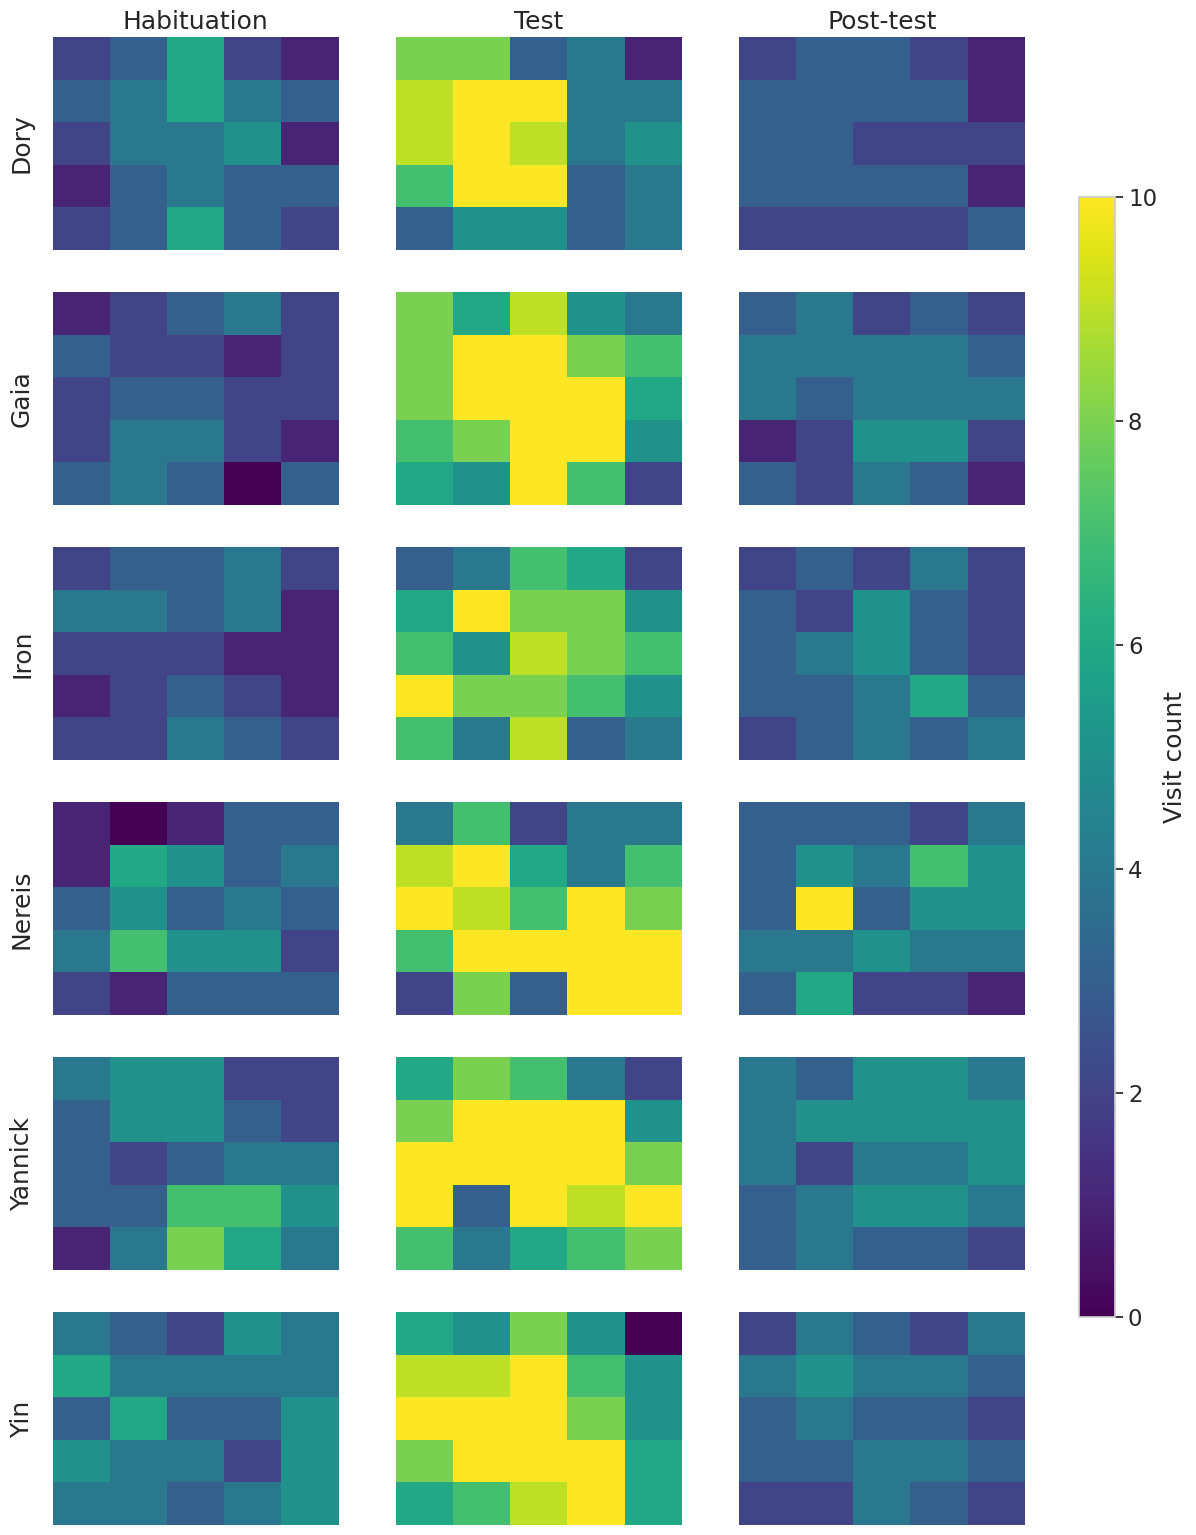

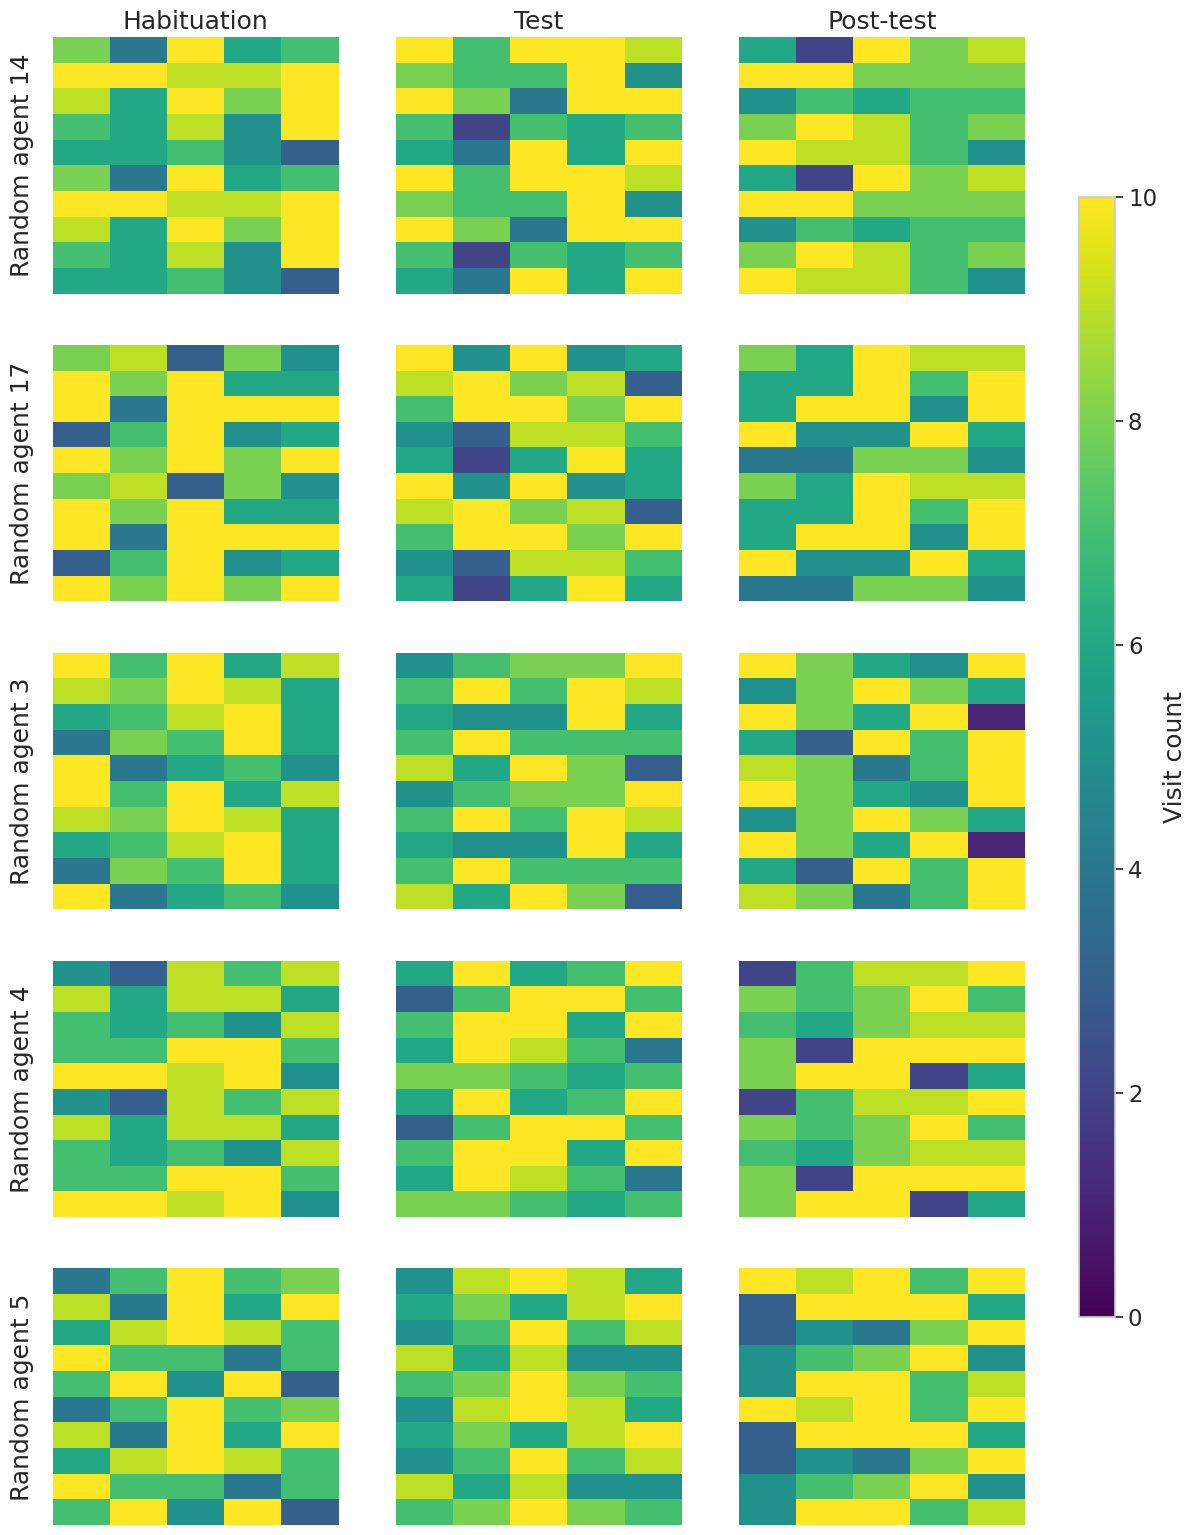

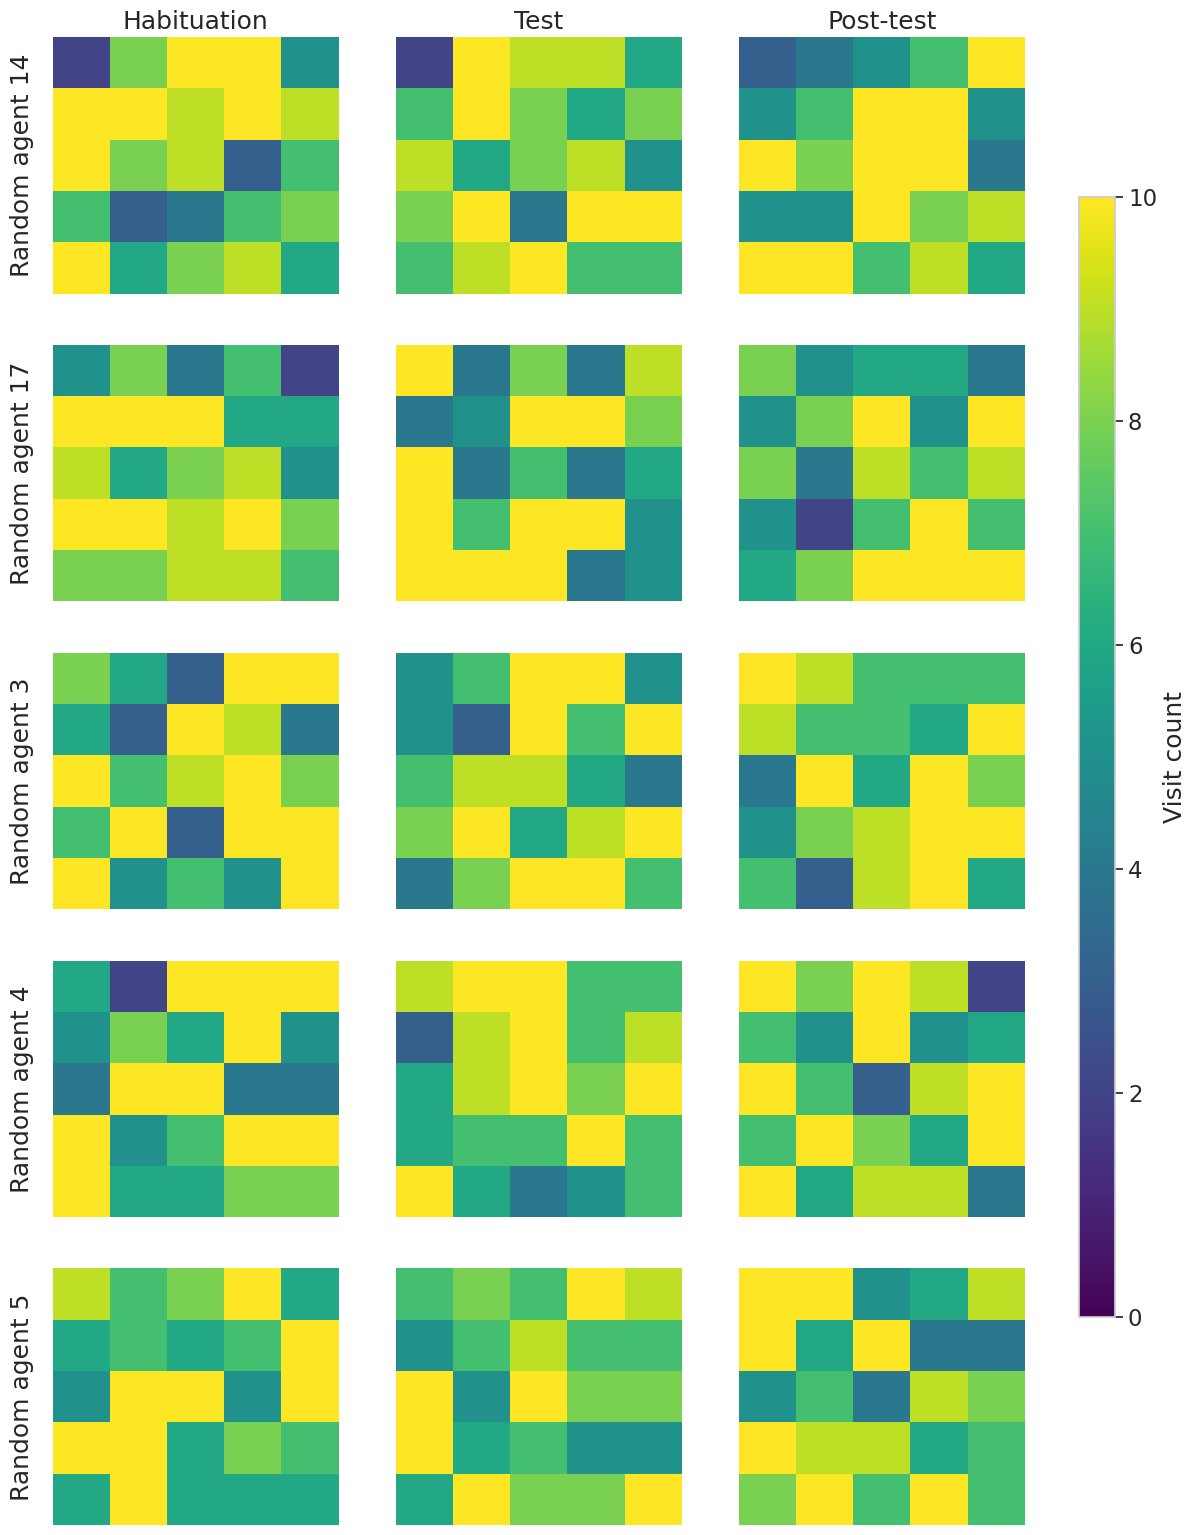

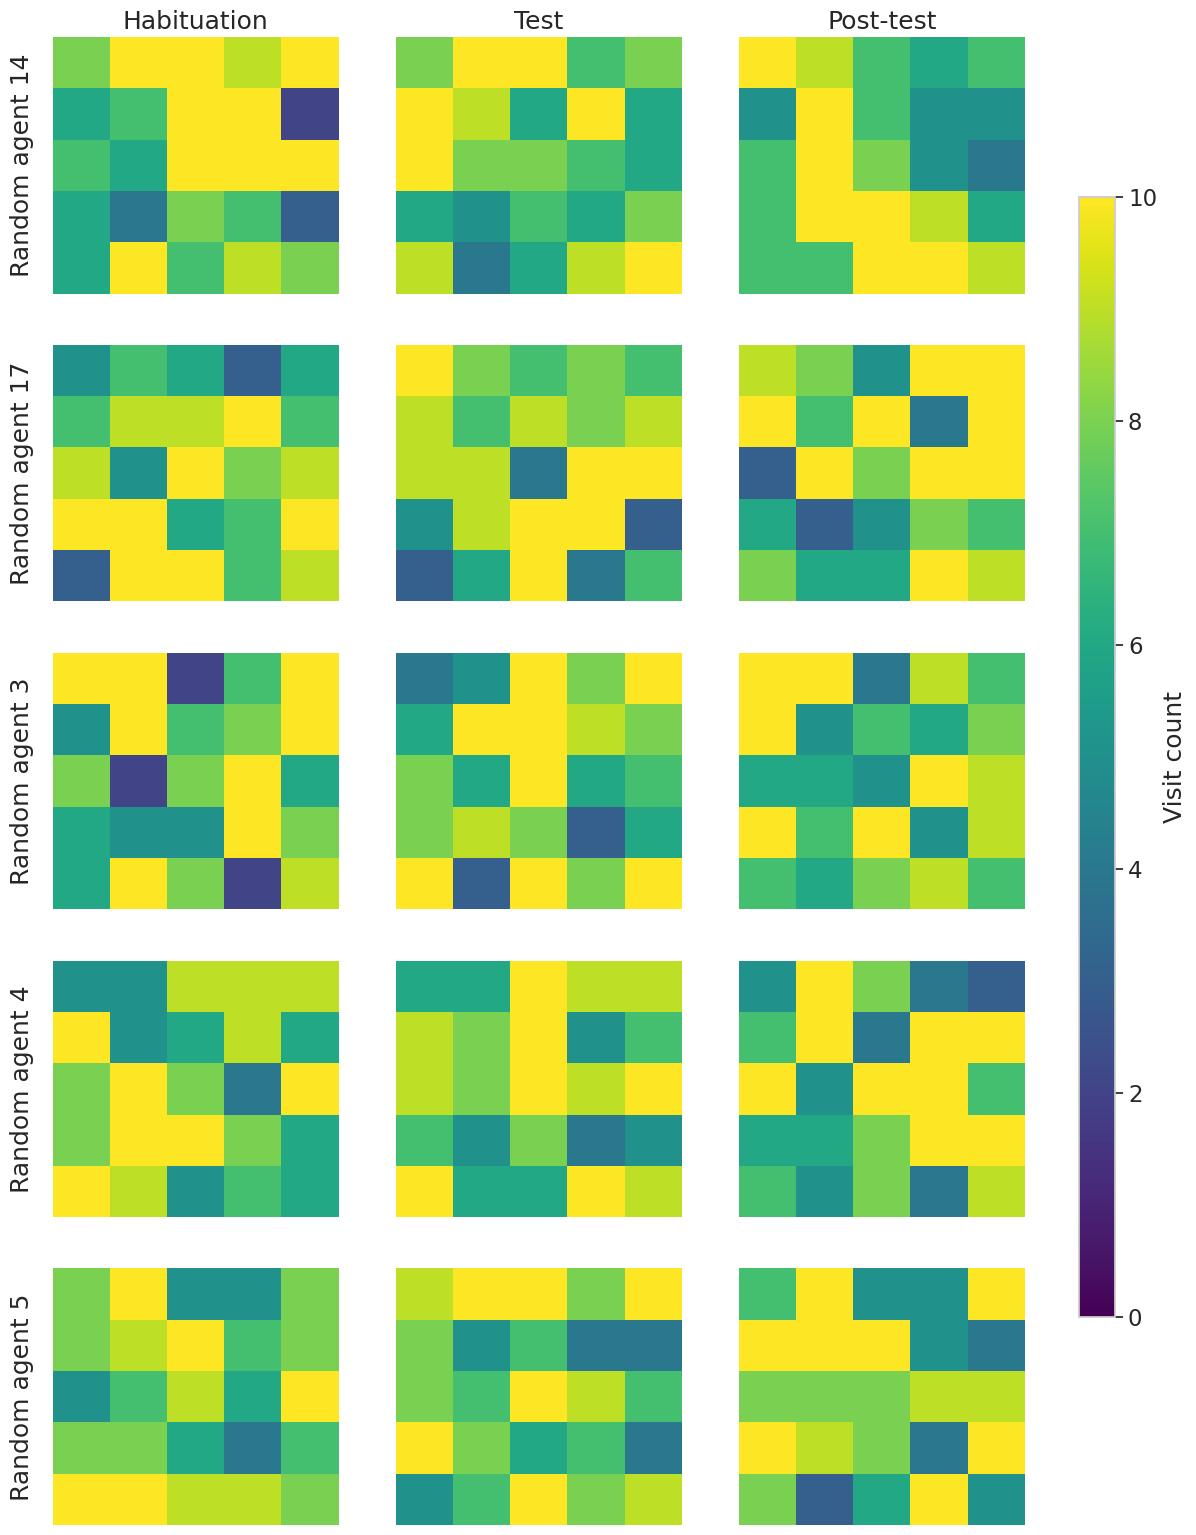

In [129]:
for grp in compare_visit_map.groupby(['Species','type']):
    num_sub = len(grp[1]['Subject'].unique())
    rows,cols = num_sub, 3
    fig,ax = pl.subplots(rows,cols,figsize=(12,16))
    
    for i,sub in enumerate(grp[1].groupby('Subject')):
        for j,ph in enumerate(phase_order):
            sl = sub[1].loc[sub[1]['Phase']==ph].copy()
            hm = sns.heatmap(sl[sl.columns[:5]],annot=False, cbar=False, ax=ax[i][j], vmin=0,vmax=10,cmap='viridis')
    
            if i == 0:
                ax[i][j].set_title(phase_order[j])
            ax[i][j].set_xticklabels([])
            ax[i][j].set_yticklabels([])
        ax[i][0].set_ylabel(sub[0])
        mappable = hm.collections[0]

    cbar_ax = fig.add_axes([0.915, 0.15, 0.03, 0.7])

    fig.colorbar(
        mappable,
        cax=cbar_ax,
        label="Visit count"
    )        
#     pl.tight_layout()
    fig.subplots_adjust(right=0.87,top=0.95,left=0.06,bottom=0.02)
    fig.savefig(fig_dir+"Visit_heat_map_"+grp[0][0]+"_"+grp[0][1]+"_model_comparison_"+".png")


In [130]:
compare_visit_map

,1,2,3,4,5,type,Subject,Phase,Species
1,0.0,1.0,3.0,2.0,2.0,data,Amidala,Habituation,Macaca_mulatta
2,2.0,4.0,5.0,5.0,4.0,data,Amidala,Habituation,Macaca_mulatta
3,5.0,6.0,5.0,4.0,5.0,data,Amidala,Habituation,Macaca_mulatta
4,5.0,4.0,6.0,5.0,4.0,data,Amidala,Habituation,Macaca_mulatta
5,5.0,4.0,6.0,4.0,4.0,data,Amidala,Habituation,Macaca_mulatta
...,...,...,...,...,...,...,...,...,...
1,6.0,5.0,8.0,5.0,0.0,model - B,Yin,Test,Macaca_tonkeana
2,9.0,9.0,12.0,7.0,5.0,model - B,Yin,Test,Macaca_tonkeana
3,10.0,11.0,14.0,8.0,5.0,model - B,Yin,Test,Macaca_tonkeana
4,8.0,12.0,10.0,12.0,6.0,model - B,Yin,Test,Macaca_tonkeana


In [131]:
to_plot = model_fittings.melt(id_vars=['Subject','Species','Phase','NLL_per_choice','Model','BIC','NLL','Random_NLL_per_choice','nchoices','success'])

to_plot = to_plot.loc[~to_plot['variable'].str.contains('Unnamed')]
to_plot

,Subject,Species,Phase,NLL_per_choice,Model,BIC,NLL,Random_NLL_per_choice,nchoices,success,variable,value
0,Amidala,Macaca_mulatta,Habituation,2.410603,A,494.445537,229.007261,3.218876,95,True,W(row_scan),0.331072
1,Amidala,Macaca_mulatta,Post-test,2.088586,A,433.262445,198.415715,3.218876,95,True,W(row_scan),0.438479
2,Amidala,Macaca_mulatta,Test,2.262556,A,901.747443,429.885625,3.218876,190,True,W(row_scan),0.271542
3,Anyanka,Macaca_mulatta,Habituation,2.032862,A,422.674848,193.121916,3.218876,95,True,W(row_scan),0.370719
4,Anyanka,Macaca_mulatta,Post-test,2.059816,A,427.796055,195.682520,3.218876,95,True,W(row_scan),0.460905
...,...,...,...,...,...,...,...,...,...,...,...,...
1135,Yannick,Macaca_tonkeana,Post-test,1.663184,B,356.989813,158.002461,3.218876,95,True,W(reward_availability),NaN
1136,Yannick,Macaca_tonkeana,Test,2.057631,B,829.123038,390.949910,3.218876,190,True,W(reward_availability),NaN
1137,Yin,Macaca_tonkeana,Habituation,2.535876,B,522.801417,240.908263,3.218876,95,True,W(reward_availability),NaN
1138,Yin,Macaca_tonkeana,Post-test,2.284178,B,386.171624,173.597512,3.218876,76,True,W(reward_availability),NaN


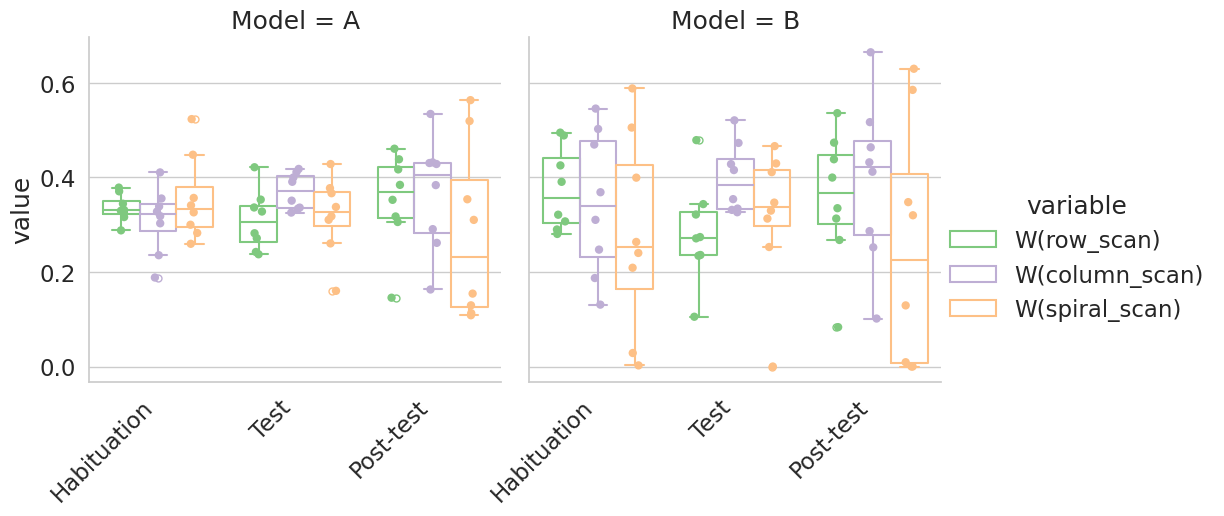

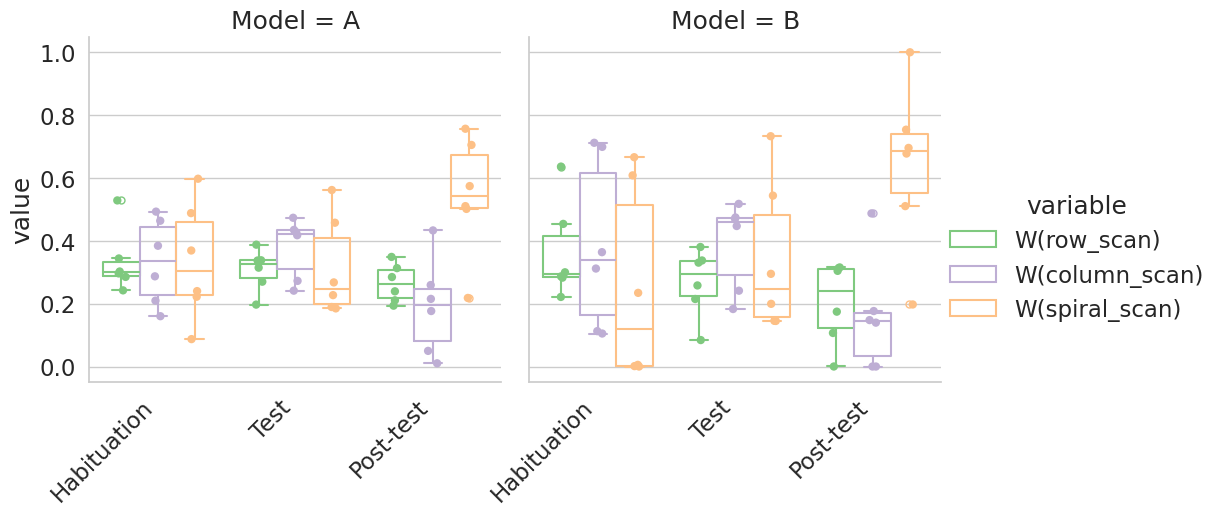

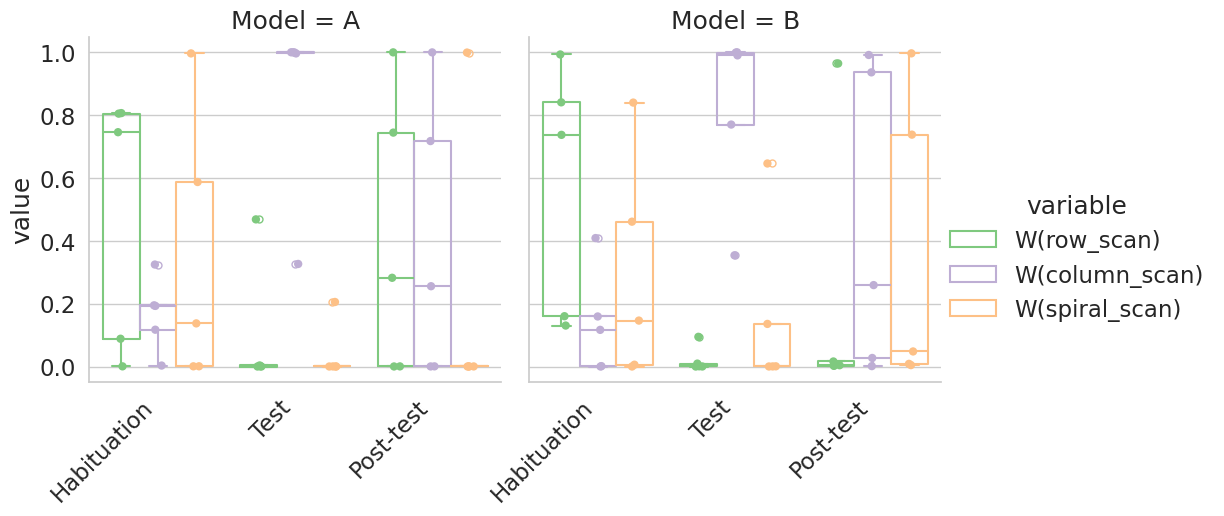

In [132]:
weights_spatial_df = to_plot.loc[to_plot['variable'].str.contains('_scan')].copy()
weights_other_df = to_plot.loc[(to_plot['variable'].str.contains('W')&~(to_plot['variable'].str.contains('_scan')))].copy()

for grp in weights_spatial_df.groupby('Species'):
    g1_sp_wt = plot_boxplots_with_points("Phase","value","Model",'variable',phase_order,cmap1,grp[1],2,True,True)
    g1_sp_wt.savefig(fig_dir+"comparison_weights_with_points_spatial_mix_"+grp[0]+".png")    

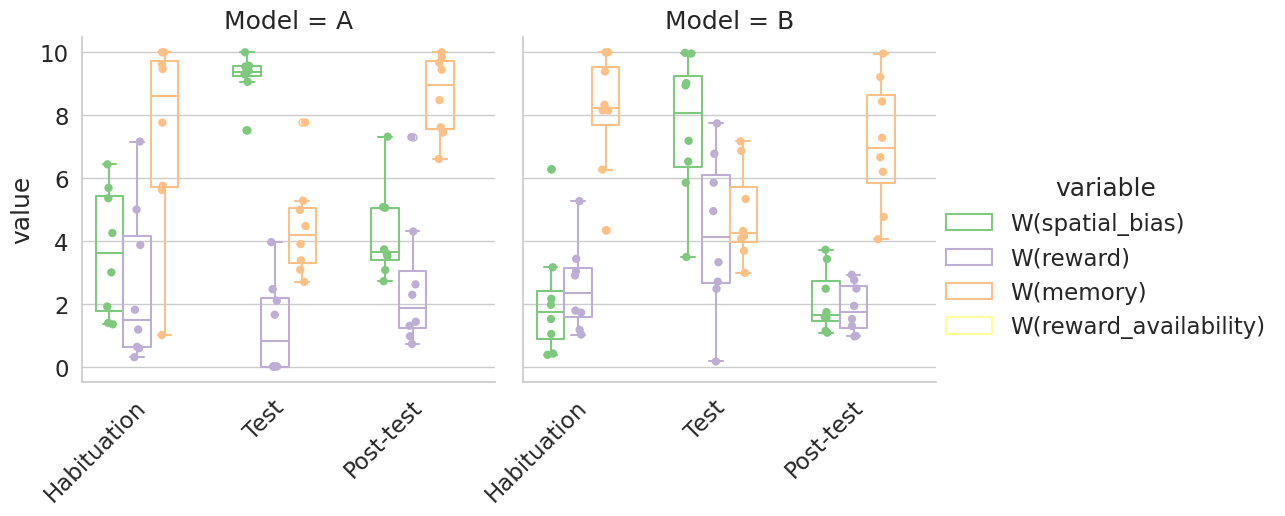

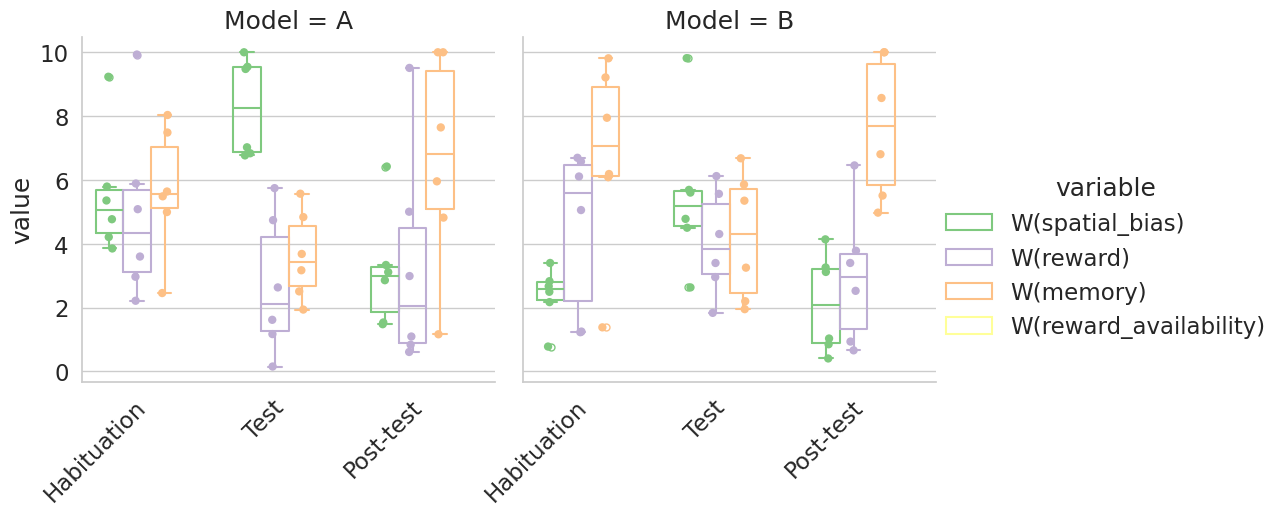

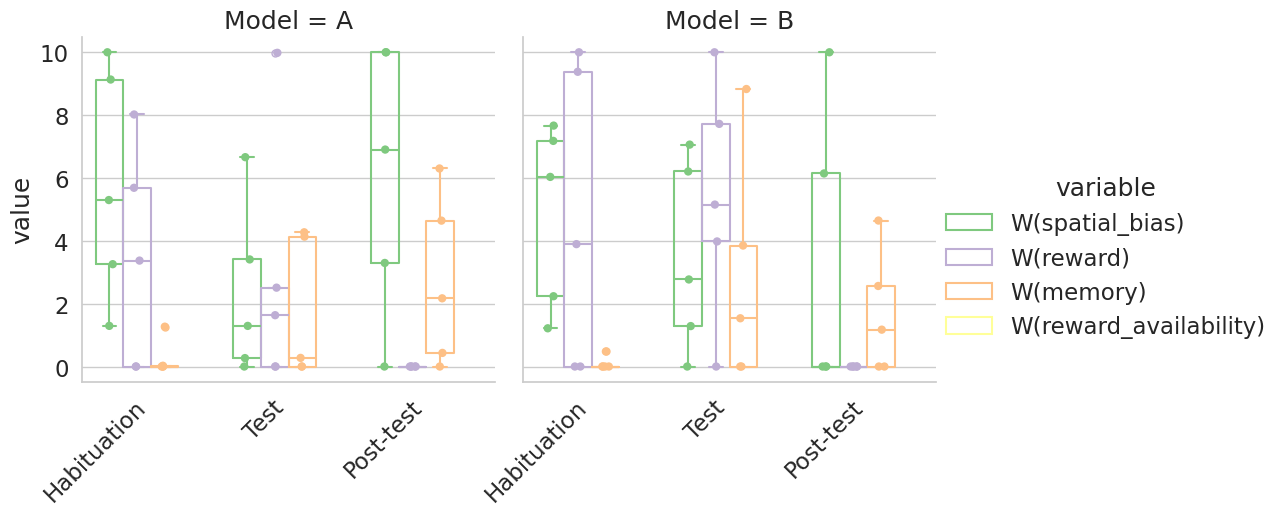

In [134]:
for grp in weights_other_df.groupby('Species'):    
    g1_oth_wt = plot_boxplots_with_points("Phase","value",'Model','variable',phase_order,cmap1,grp[1],2,True,True)
    g1_oth_wt.savefig(fig_dir+"comparison_weights_with_points_other_"+grp[0]+".png")    

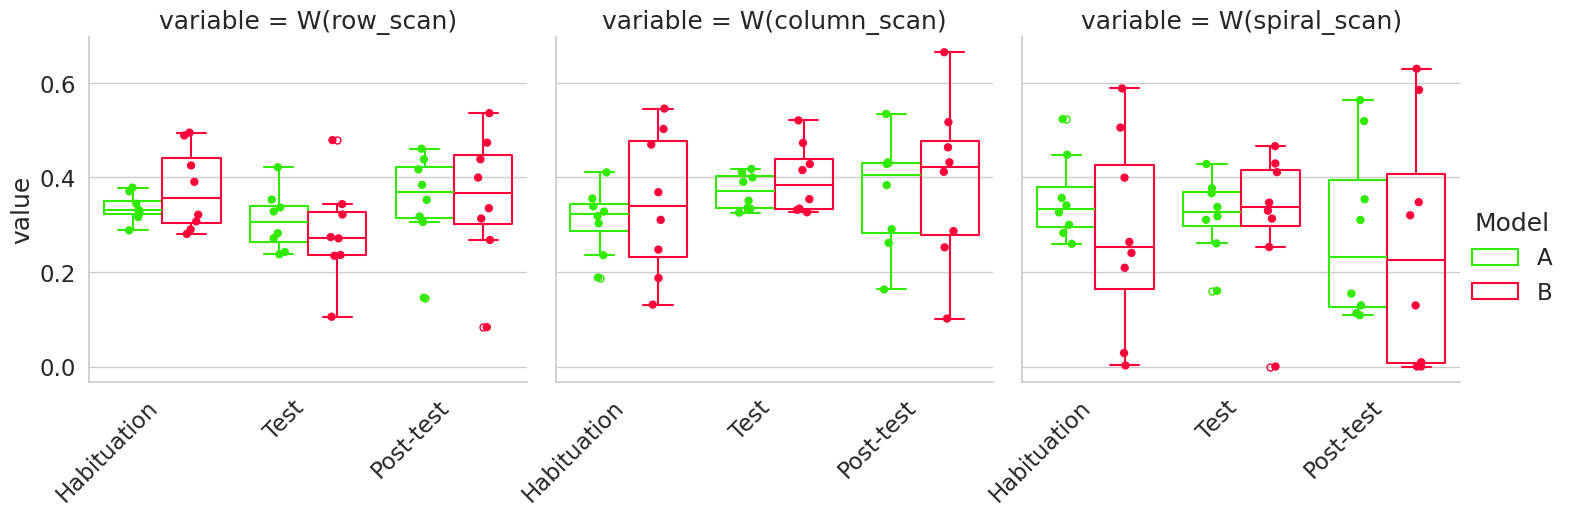

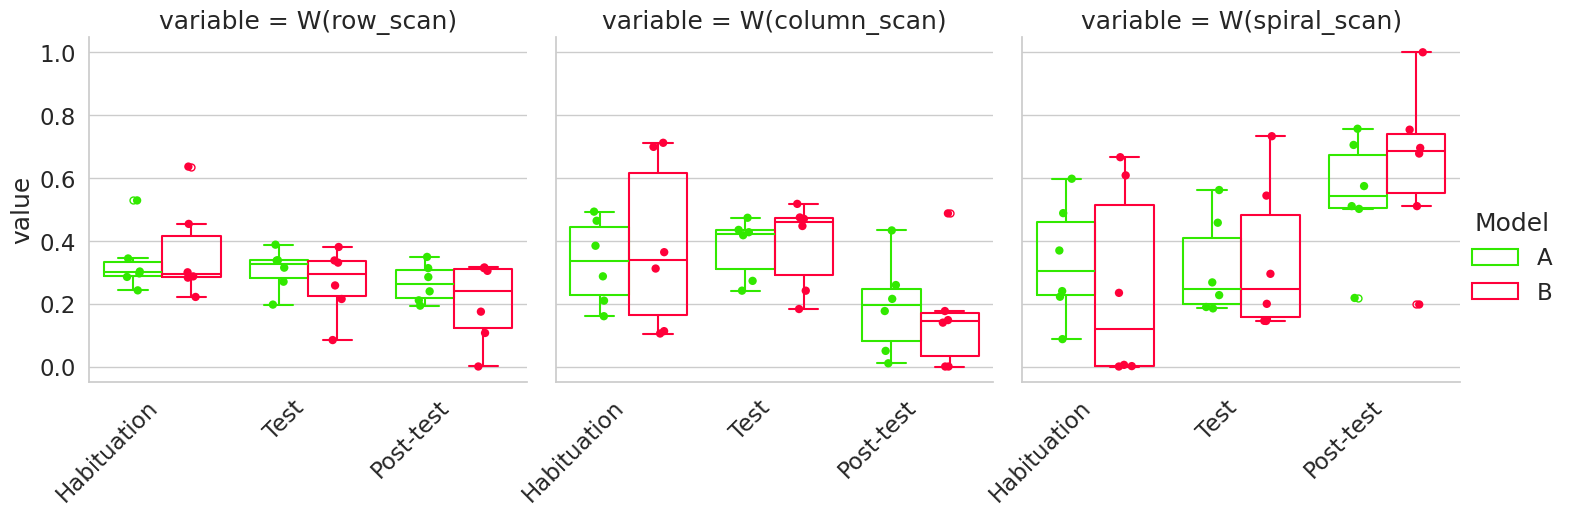

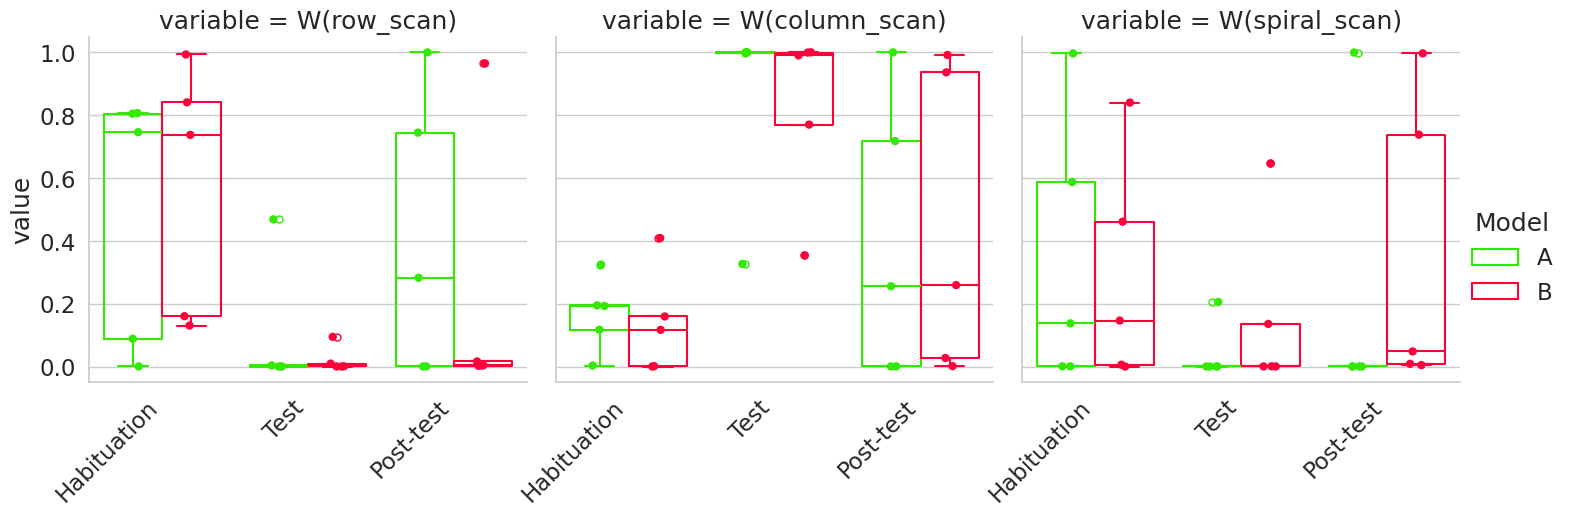

In [157]:
# for grp in weights_spatial_df.groupby('Model'):
for grp in weights_spatial_df.groupby('Species'):
    g1_sp_wt = plot_boxplots_with_points("Phase","value",'variable','Model',phase_order,cmap3,grp[1],3,True,True)

    g1_sp_wt.savefig(fig_dir+"comparison_weights_with_points1_spatial_mix_model_comparison_"+grp[0]+".png")    


In [136]:
other_pars = to_plot.loc[~(to_plot['variable'].str.contains('W')|(to_plot['variable'].str.contains('nchoices')))]
other_pars

,Subject,Species,Phase,NLL_per_choice,Model,BIC,NLL,Random_NLL_per_choice,nchoices,success,variable,value
684,Amidala,Macaca_mulatta,Habituation,2.410603,A,494.445537,229.007261,3.218876,95,True,memory_recall,0.906126
685,Amidala,Macaca_mulatta,Post-test,2.088586,A,433.262445,198.415715,3.218876,95,True,memory_recall,0.933732
686,Amidala,Macaca_mulatta,Test,2.262556,A,901.747443,429.885625,3.218876,190,True,memory_recall,0.604395
687,Anyanka,Macaca_mulatta,Habituation,2.032862,A,422.674848,193.121916,3.218876,95,True,memory_recall,0.978855
688,Anyanka,Macaca_mulatta,Post-test,2.059816,A,427.796055,195.682520,3.218876,95,True,memory_recall,0.904042
...,...,...,...,...,...,...,...,...,...,...,...,...
1021,Yannick,Macaca_tonkeana,Post-test,1.663184,B,356.989813,158.002461,3.218876,95,True,reward_decay,0.500000
1022,Yannick,Macaca_tonkeana,Test,2.057631,B,829.123038,390.949910,3.218876,190,True,reward_decay,0.500000
1023,Yin,Macaca_tonkeana,Habituation,2.535876,B,522.801417,240.908263,3.218876,95,True,reward_decay,0.500000
1024,Yin,Macaca_tonkeana,Post-test,2.284178,B,386.171624,173.597512,3.218876,76,True,reward_decay,0.999000


In [137]:
other_pars.variable.unique()

array(['memory_recall', 'beta', 'reward_decay'], dtype=object)

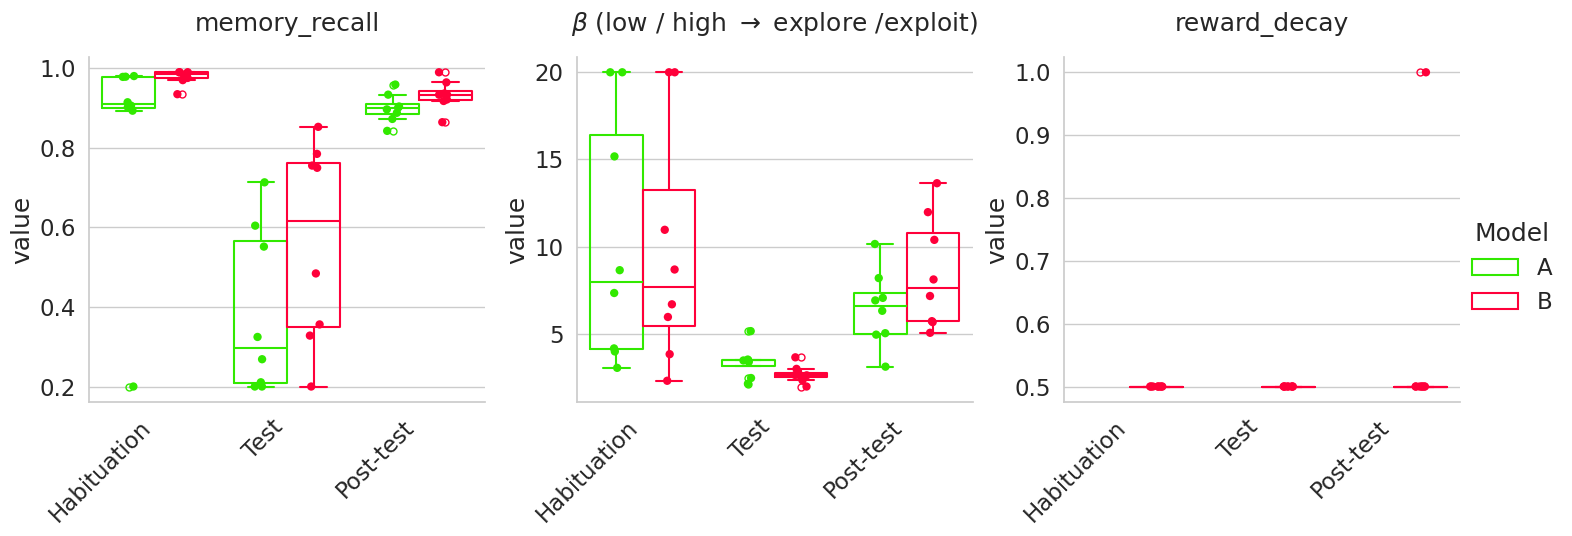

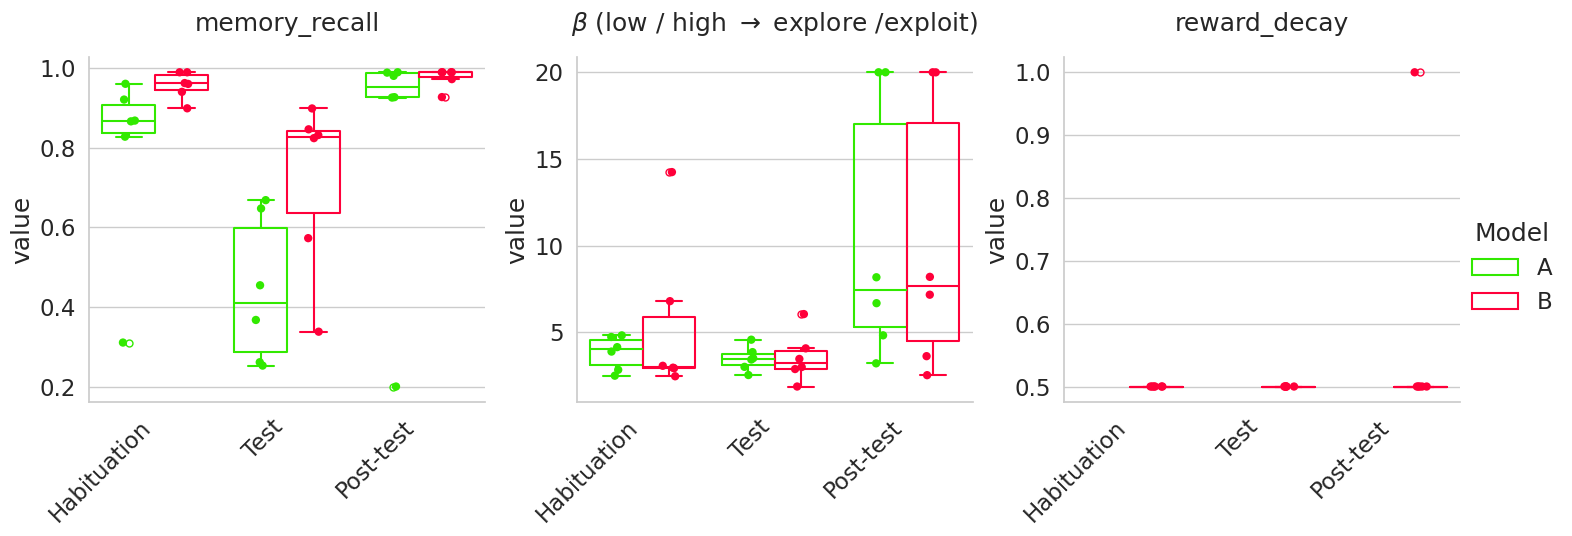

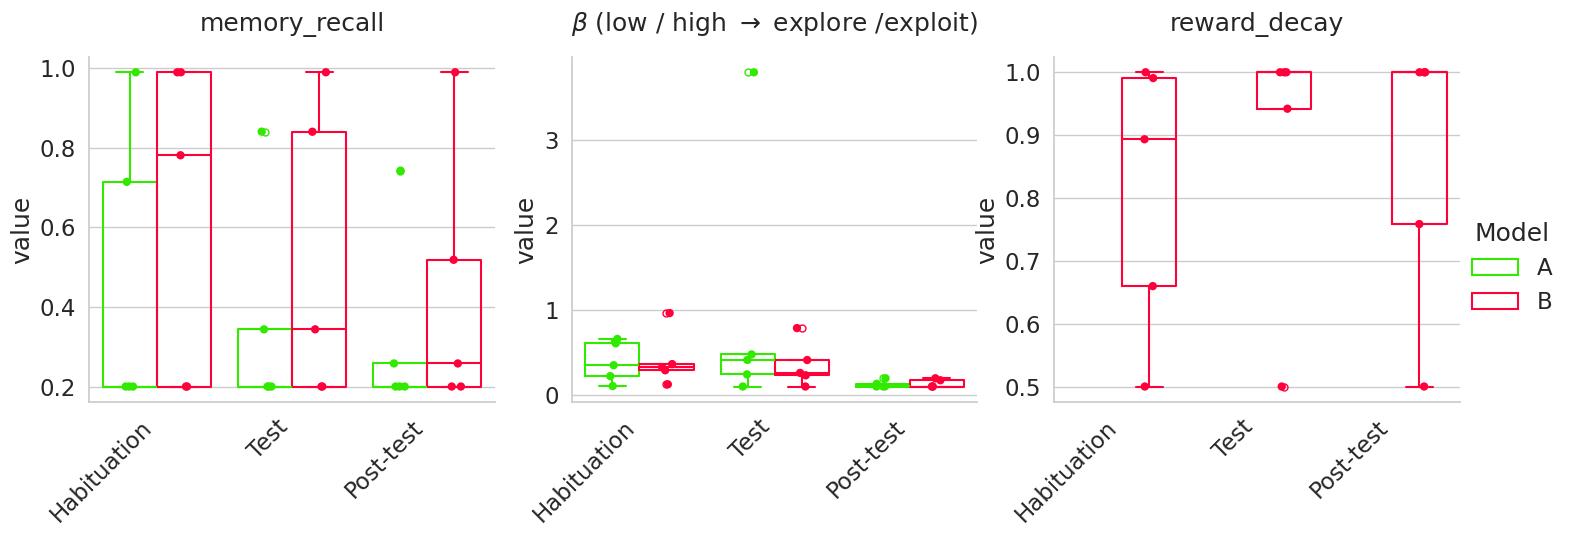

In [138]:
for grp in other_pars.groupby('Species'):
    g1_oth = plot_boxplots_with_points("Phase","value","variable",'Model',phase_order,cmap3,grp[1],3,True,False)
    for ax in g1_oth.axes:
        tit = ax.get_title().split(' = ')[1]
        if tit == 'beta':
            tit = r'$\beta$'+' (low / high '+r'$\rightarrow$'+' explore /exploit)'
        ax.set_title(tit,y=1.05)
        ax.set_xlabel("")

    g1_oth.savefig(fig_dir+"comparison_other_params_with_points_model_comparison_"+grp[0]+".png")    

In [139]:
other_pars

,Subject,Species,Phase,NLL_per_choice,Model,BIC,NLL,Random_NLL_per_choice,nchoices,success,variable,value
684,Amidala,Macaca_mulatta,Habituation,2.410603,A,494.445537,229.007261,3.218876,95,True,memory_recall,0.906126
685,Amidala,Macaca_mulatta,Post-test,2.088586,A,433.262445,198.415715,3.218876,95,True,memory_recall,0.933732
686,Amidala,Macaca_mulatta,Test,2.262556,A,901.747443,429.885625,3.218876,190,True,memory_recall,0.604395
687,Anyanka,Macaca_mulatta,Habituation,2.032862,A,422.674848,193.121916,3.218876,95,True,memory_recall,0.978855
688,Anyanka,Macaca_mulatta,Post-test,2.059816,A,427.796055,195.682520,3.218876,95,True,memory_recall,0.904042
...,...,...,...,...,...,...,...,...,...,...,...,...
1021,Yannick,Macaca_tonkeana,Post-test,1.663184,B,356.989813,158.002461,3.218876,95,True,reward_decay,0.500000
1022,Yannick,Macaca_tonkeana,Test,2.057631,B,829.123038,390.949910,3.218876,190,True,reward_decay,0.500000
1023,Yin,Macaca_tonkeana,Habituation,2.535876,B,522.801417,240.908263,3.218876,95,True,reward_decay,0.500000
1024,Yin,Macaca_tonkeana,Post-test,2.284178,B,386.171624,173.597512,3.218876,76,True,reward_decay,0.999000


In [140]:
model_fittings

,Model,Subject,Phase,Species,NLL,NLL_per_choice,Random_NLL_per_choice,nchoices,success,W(row_scan),W(column_scan),W(spiral_scan),W(spatial_bias),W(reward),W(memory),memory_recall,beta,reward_decay,W(reward_availability),BIC
0,A,Amidala,Habituation,Macaca_mulatta,229.007261,2.410603,3.218876,95,True,0.331072,0.327906,0.341022,5.361216,5.000798,9.467403,0.906126,3.986949,NaN,NaN,494.445537
1,A,Amidala,Post-test,Macaca_mulatta,198.415715,2.088586,3.218876,95,True,0.438479,0.432015,0.129506,3.732950,2.290798,10.000000,0.933732,6.914395,NaN,NaN,433.262445
2,A,Amidala,Test,Macaca_mulatta,429.885625,2.262556,3.218876,190,True,0.271542,0.351006,0.377452,9.292446,0.010000,5.281833,0.604395,3.470659,NaN,NaN,901.747443
3,A,Anyanka,Habituation,Macaca_mulatta,193.121916,2.032862,3.218876,95,True,0.370719,0.303076,0.326205,1.395360,0.305600,10.000000,0.978855,20.000000,NaN,NaN,422.674848
4,A,Anyanka,Post-test,Macaca_mulatta,195.682520,2.059816,3.218876,95,True,0.460905,0.430603,0.108492,2.723395,0.728422,8.479681,0.904042,10.149629,NaN,NaN,427.796055
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,B,Yannick,Post-test,Macaca_tonkeana,158.002461,1.663184,3.218876,95,True,0.315292,0.487251,0.197457,0.850516,0.934715,10.000000,0.990000,20.000000,0.500,NaN,356.989813
110,B,Yannick,Test,Macaca_tonkeana,390.949910,2.057631,3.218876,190,True,0.257994,0.447059,0.294947,5.603698,4.305053,6.678087,0.846615,3.472092,0.500,NaN,829.123038
111,B,Yin,Habituation,Macaca_tonkeana,240.908263,2.535876,3.218876,95,True,0.221408,0.112612,0.665980,2.170626,1.248283,6.185557,0.899426,6.802222,0.500,NaN,522.801417
112,B,Yin,Post-test,Macaca_tonkeana,173.597512,2.284178,3.218876,76,True,0.313100,0.176523,0.510377,3.256409,3.398171,6.805423,0.927638,7.174271,0.999,NaN,386.171624


In [158]:
# for grp in model_fittings.groupby('Species'):
#     g1 = sns.lmplot(x="beta",y="memory_recall",col='Phase',hue='Model',data=grp[1],facet_kws={'sharey':False,'sharex':False},palette=cmap3)
#     for ax in g1.axes[0]:
#         tit = ax.get_title().split(' = ')[1]
#         dat = grp[1].loc[grp[1]['Phase']==tit].copy()
#         for m in dat.groupby('Model'):
#             beta = m[1]['beta'].values
#             recall = m[1]['memory_recall'].values
#             ans = sp_st.pearsonr(beta,recall)
#             print(m[0],ans)
            

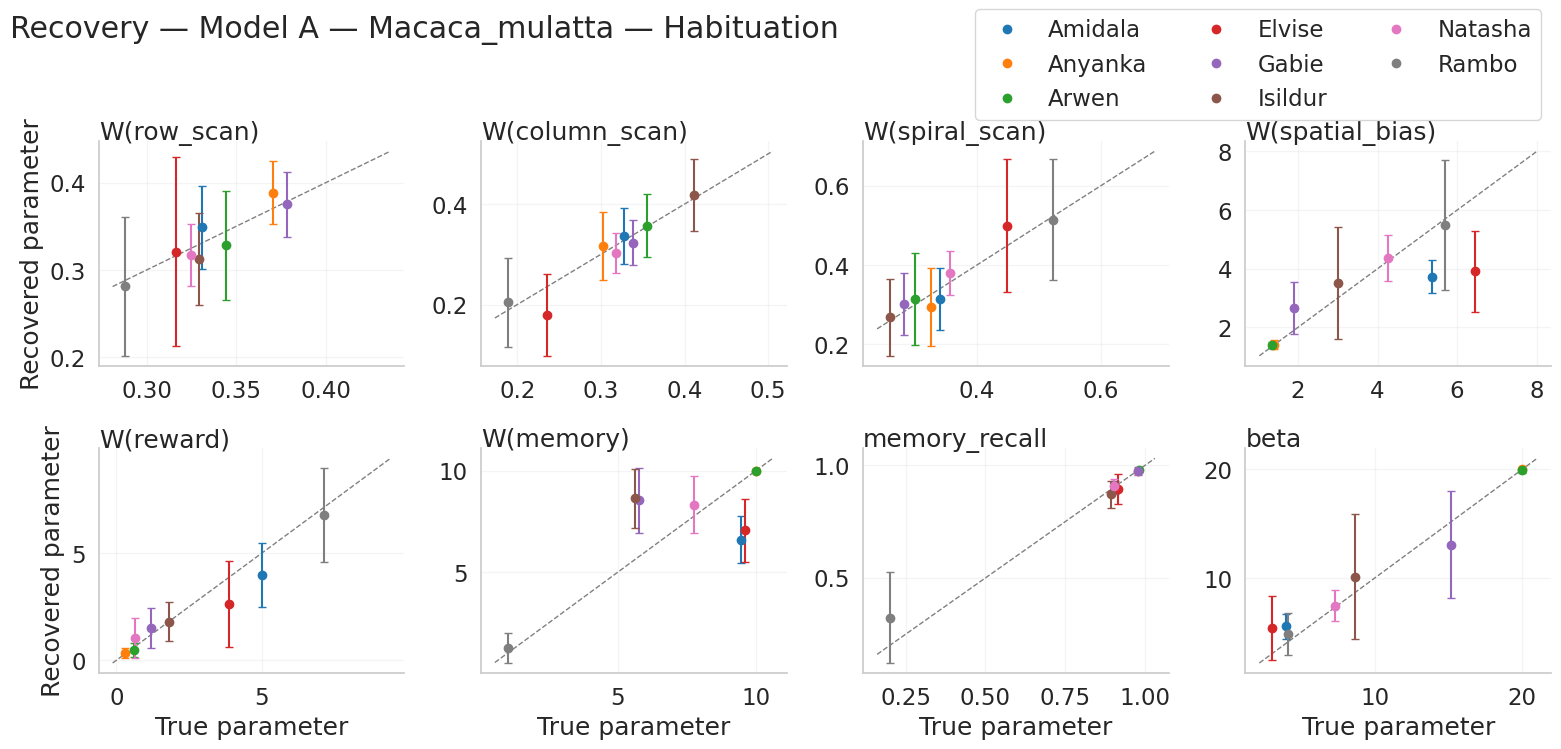

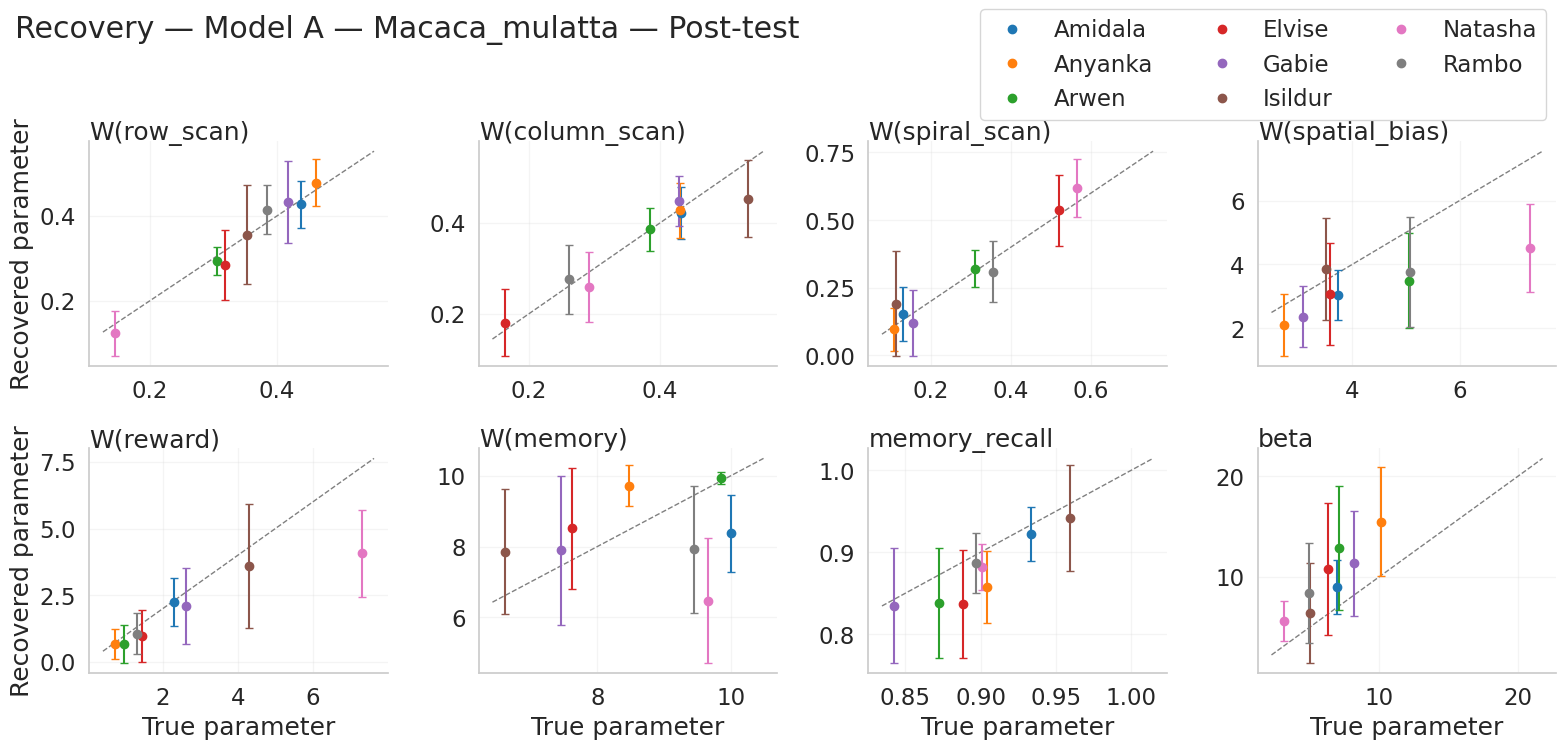

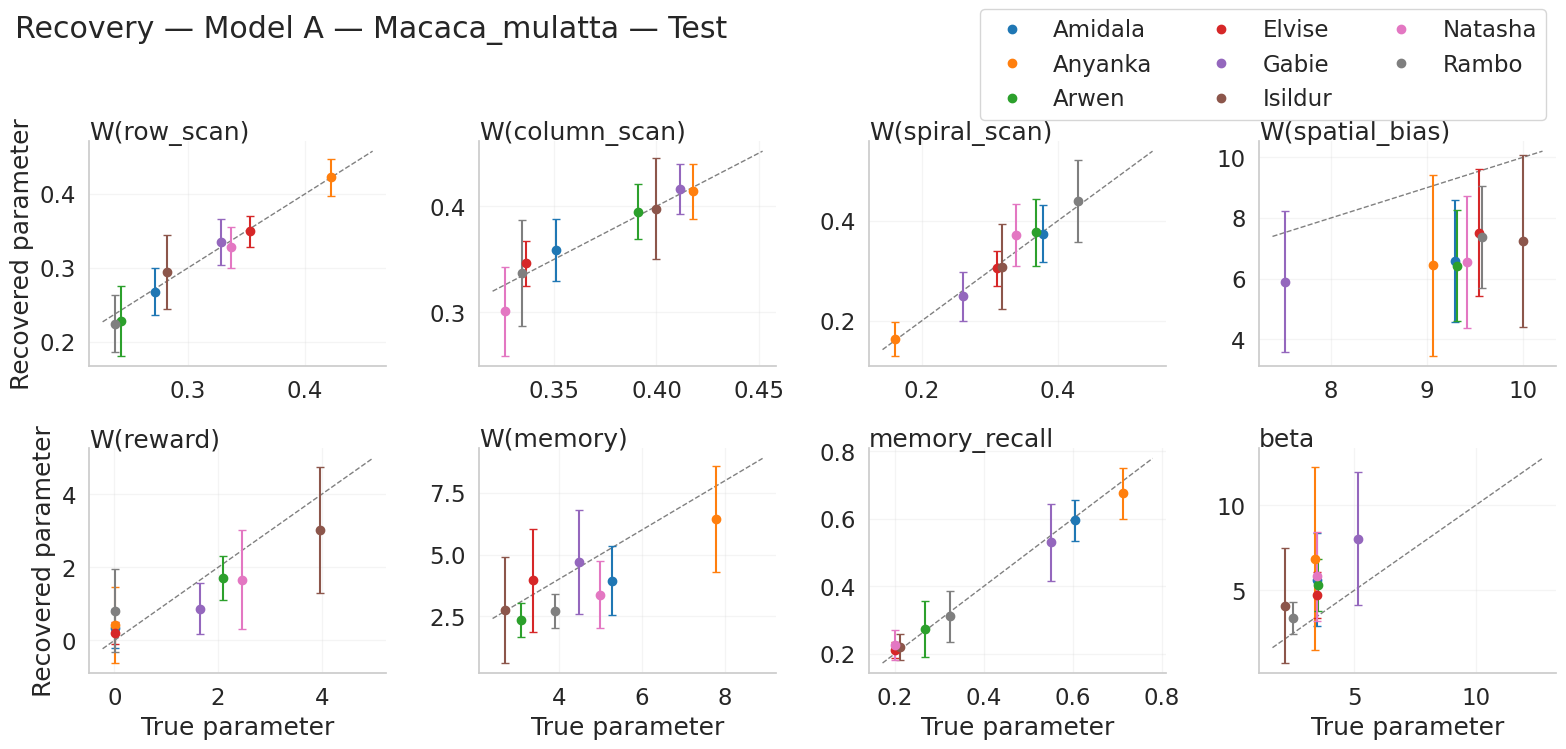

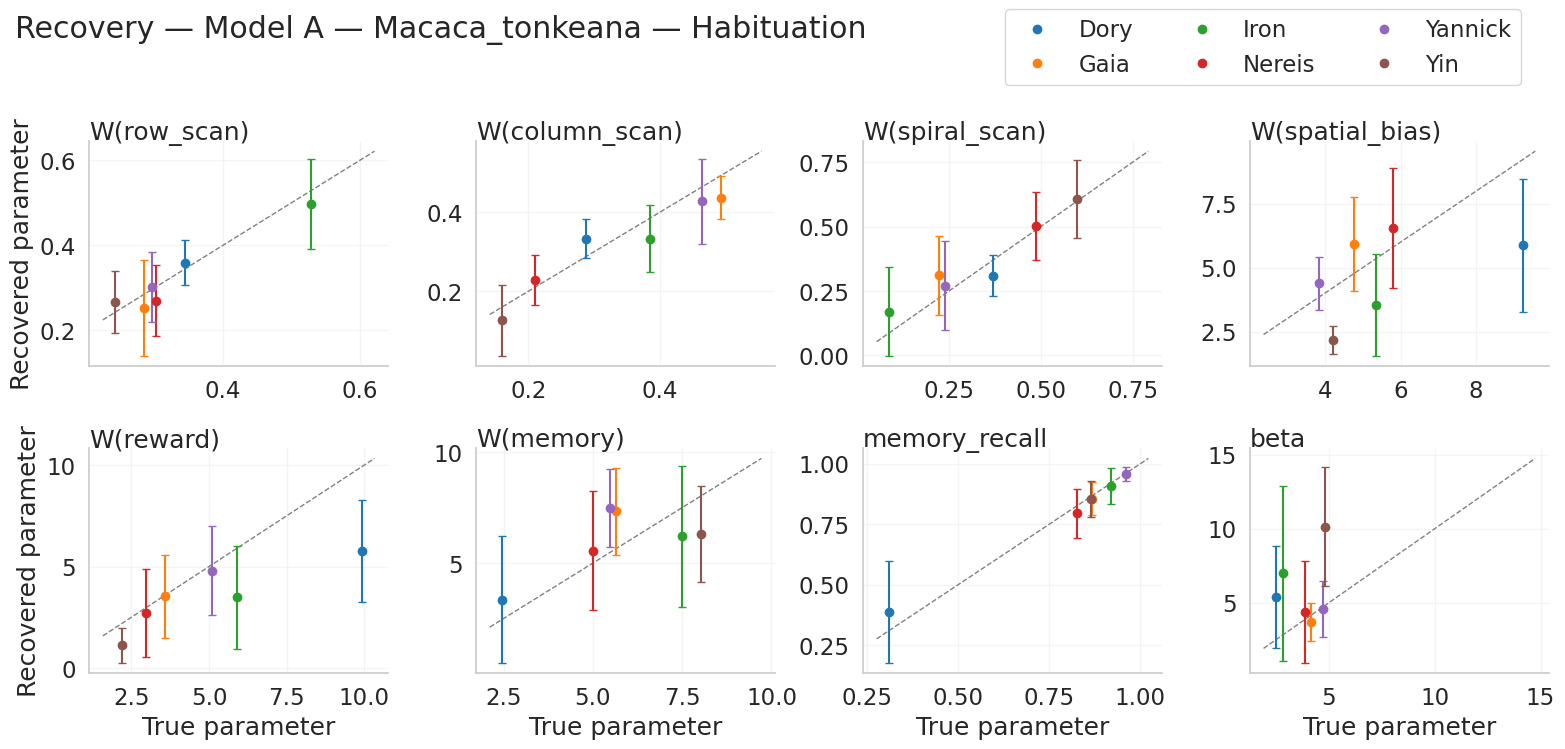

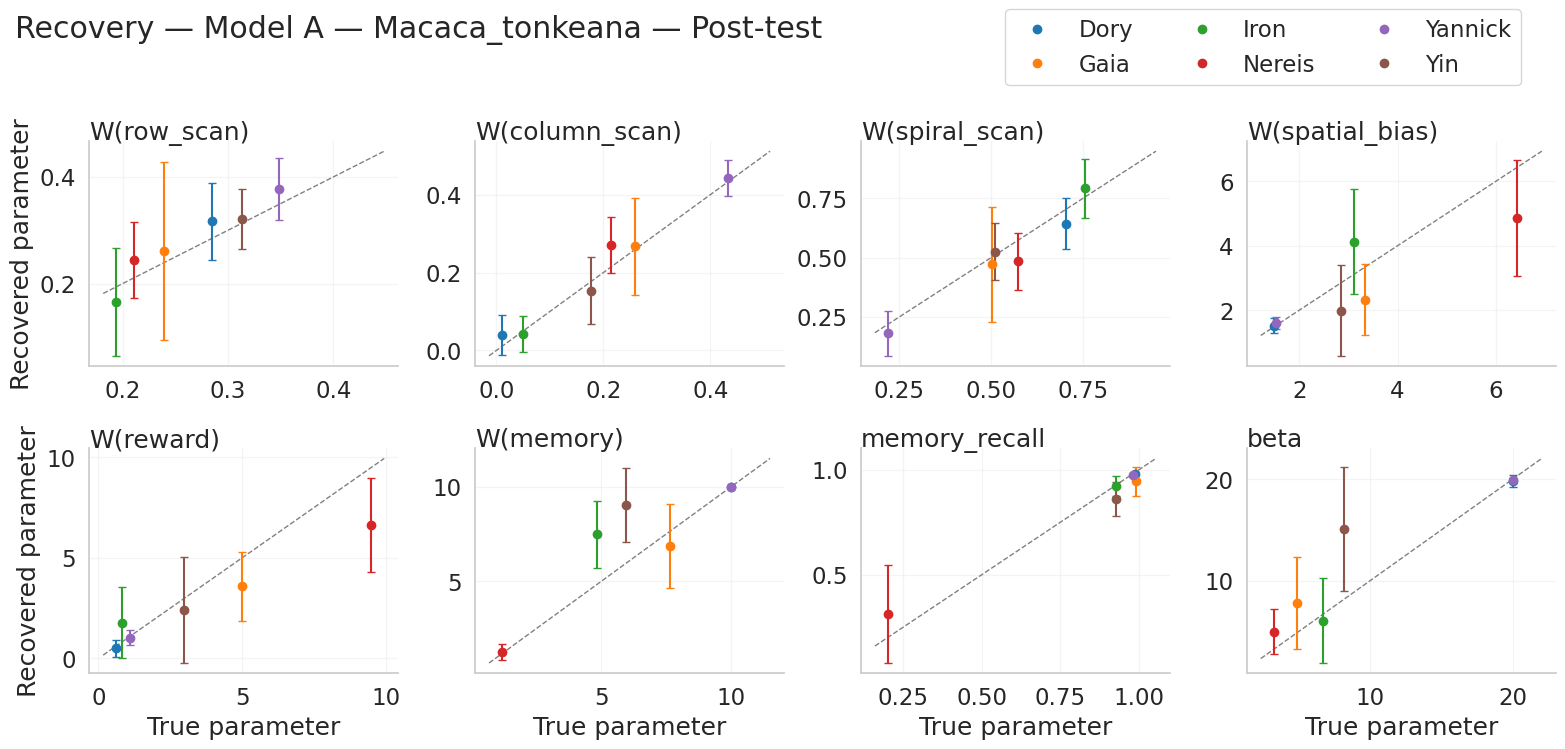

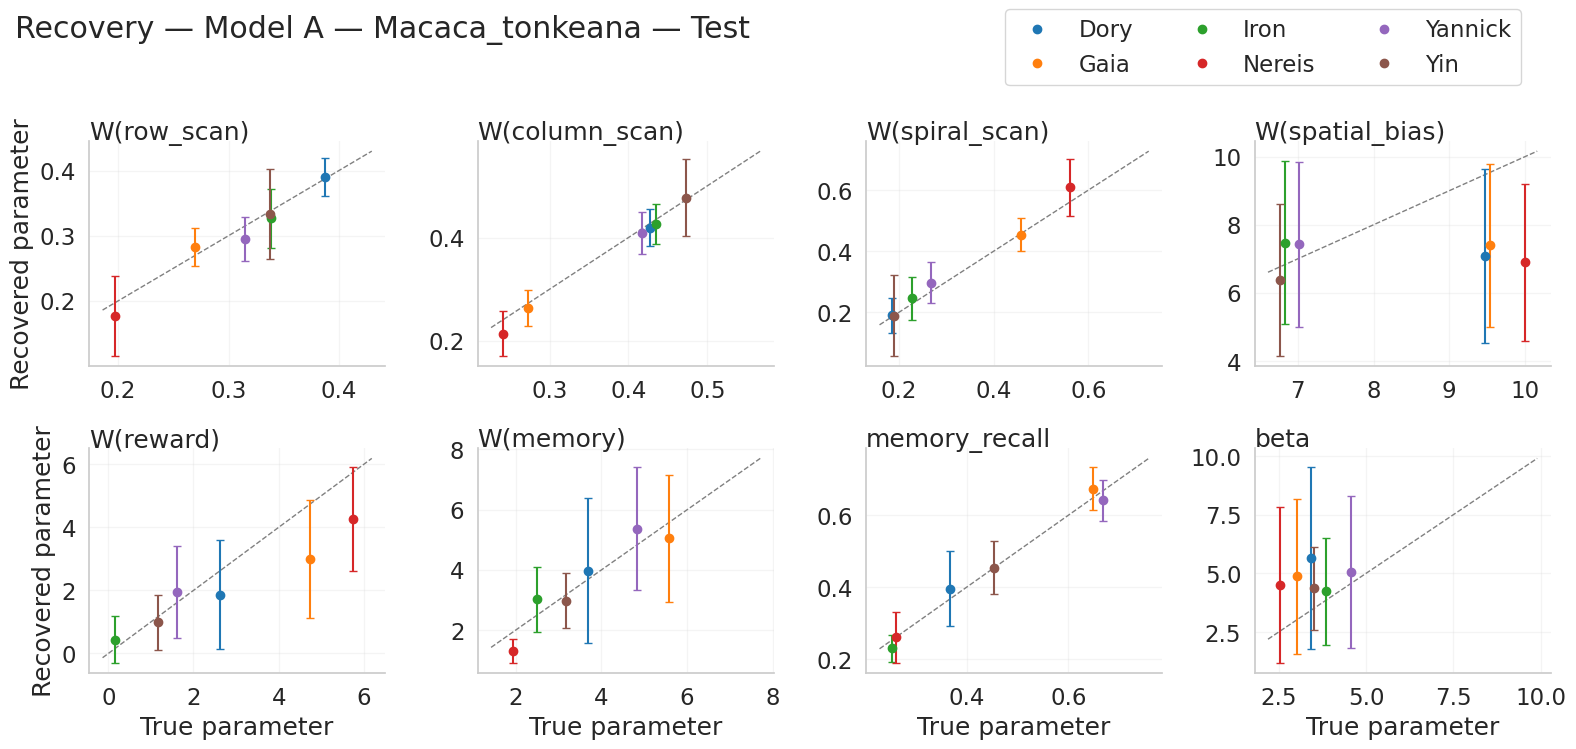

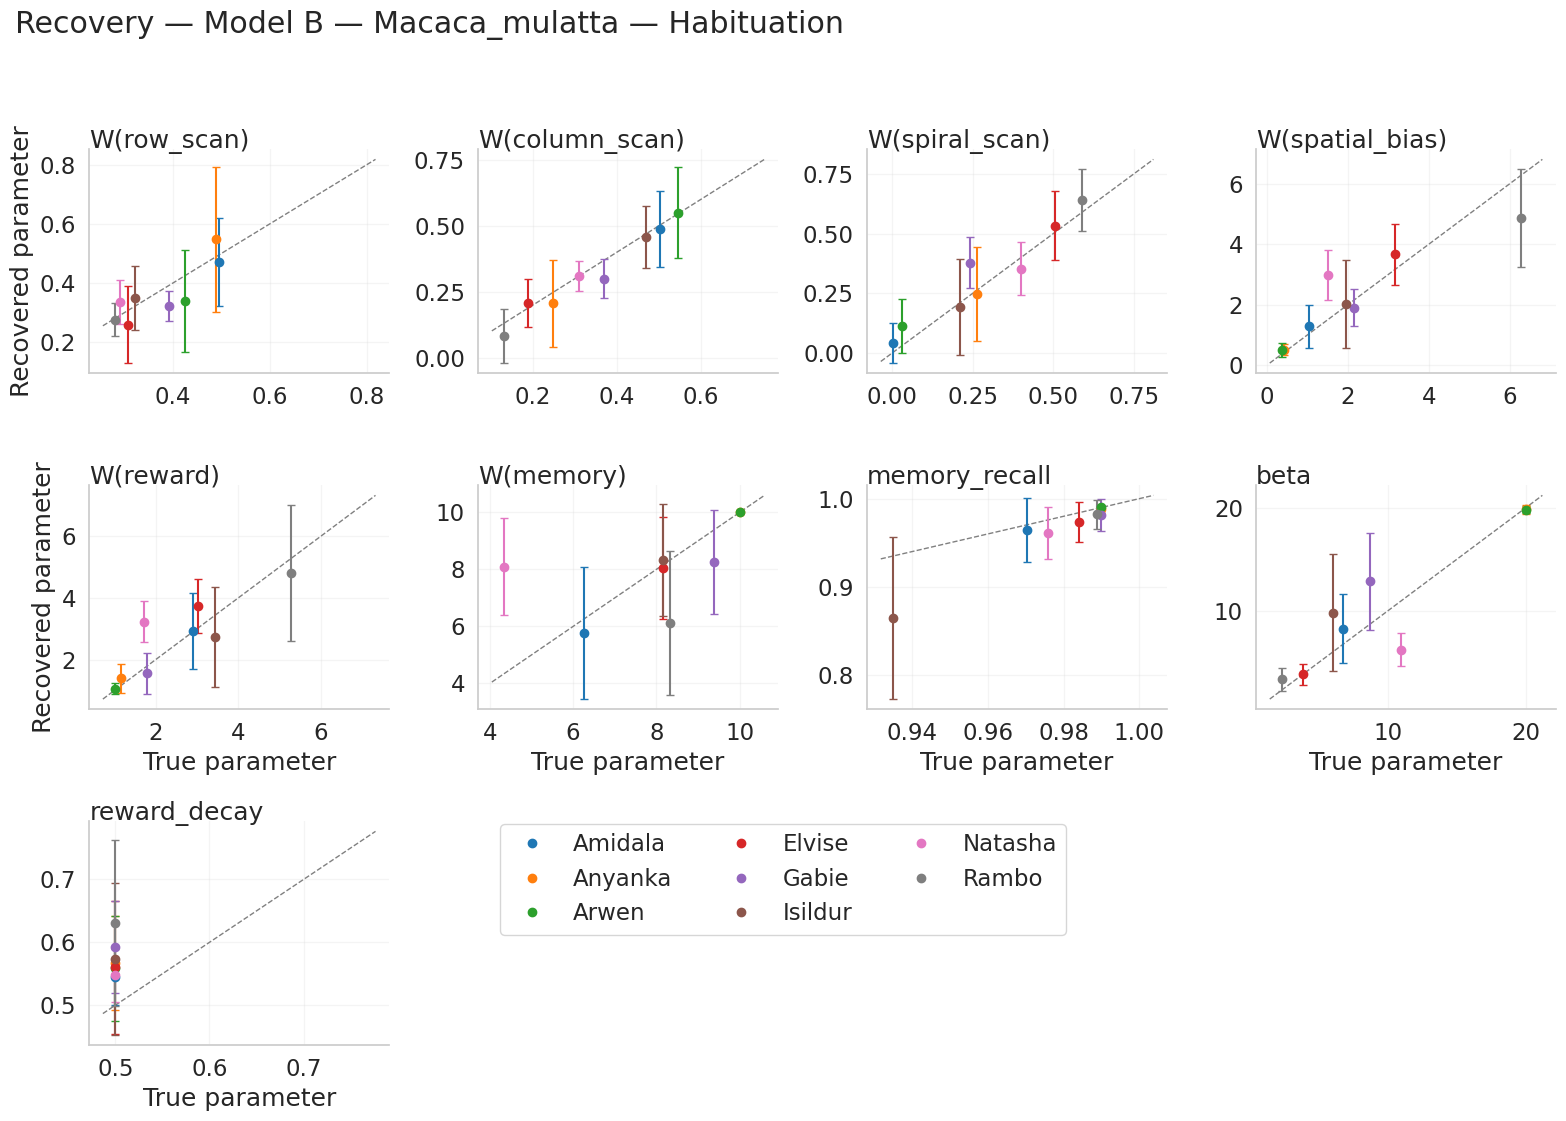

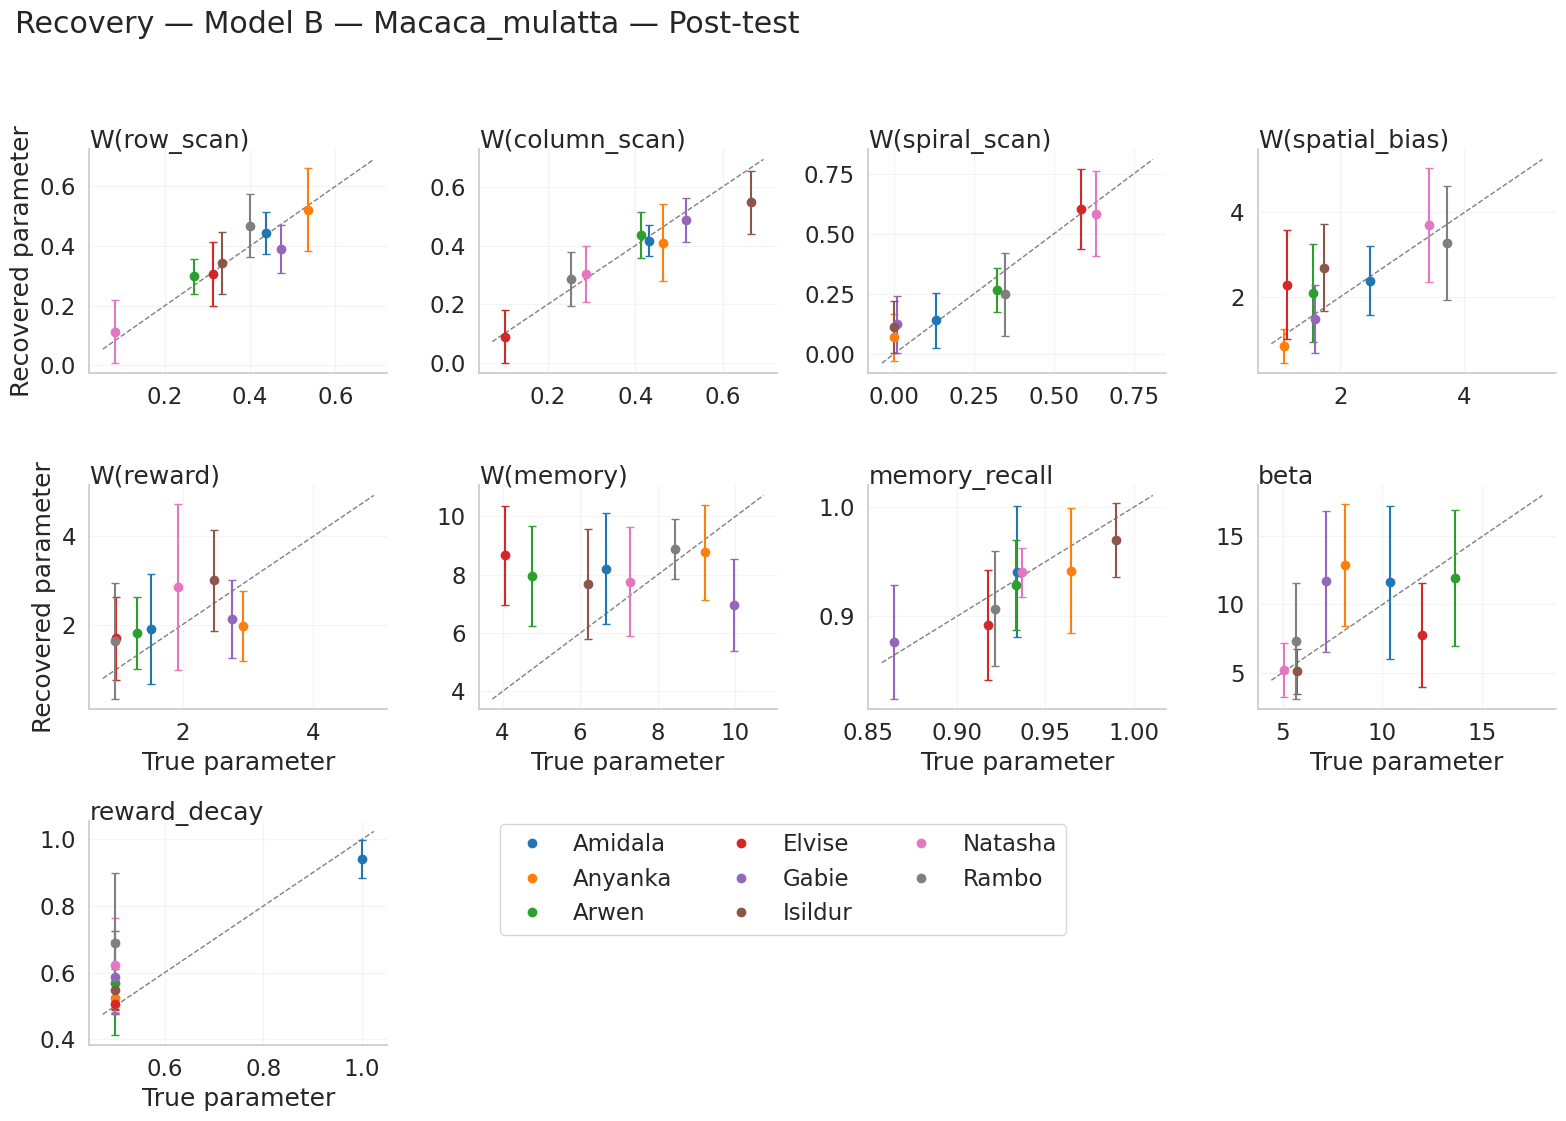

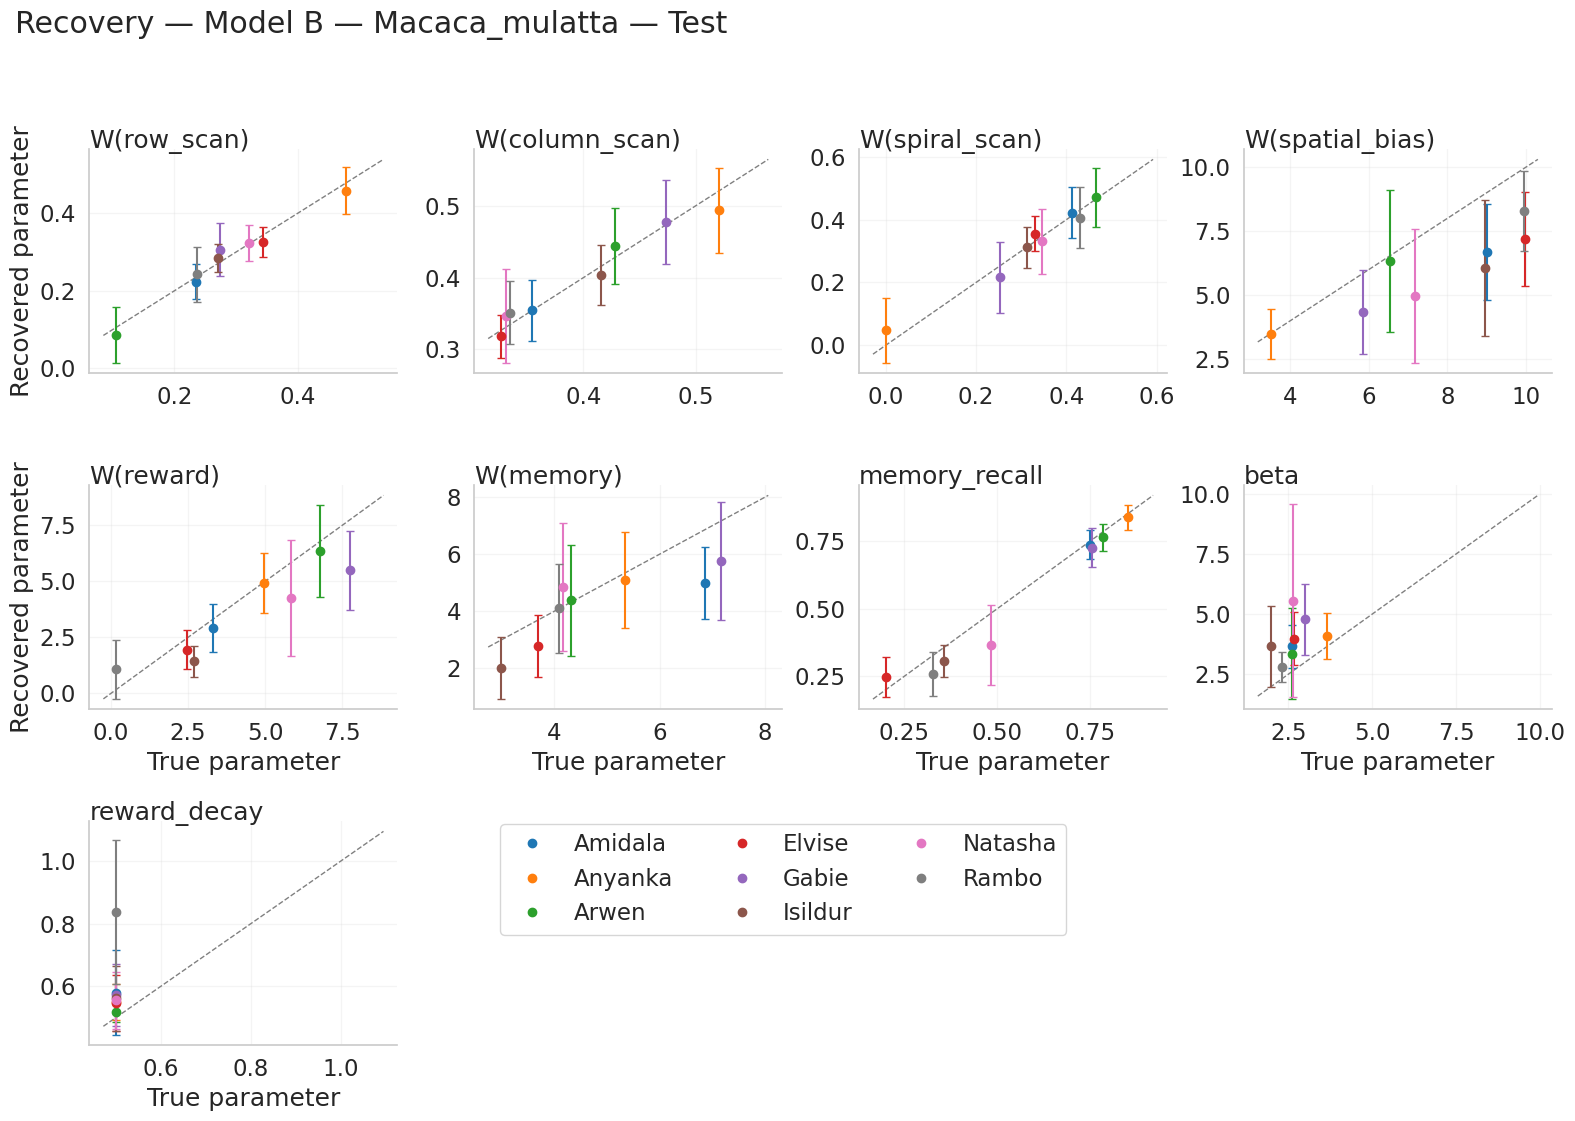

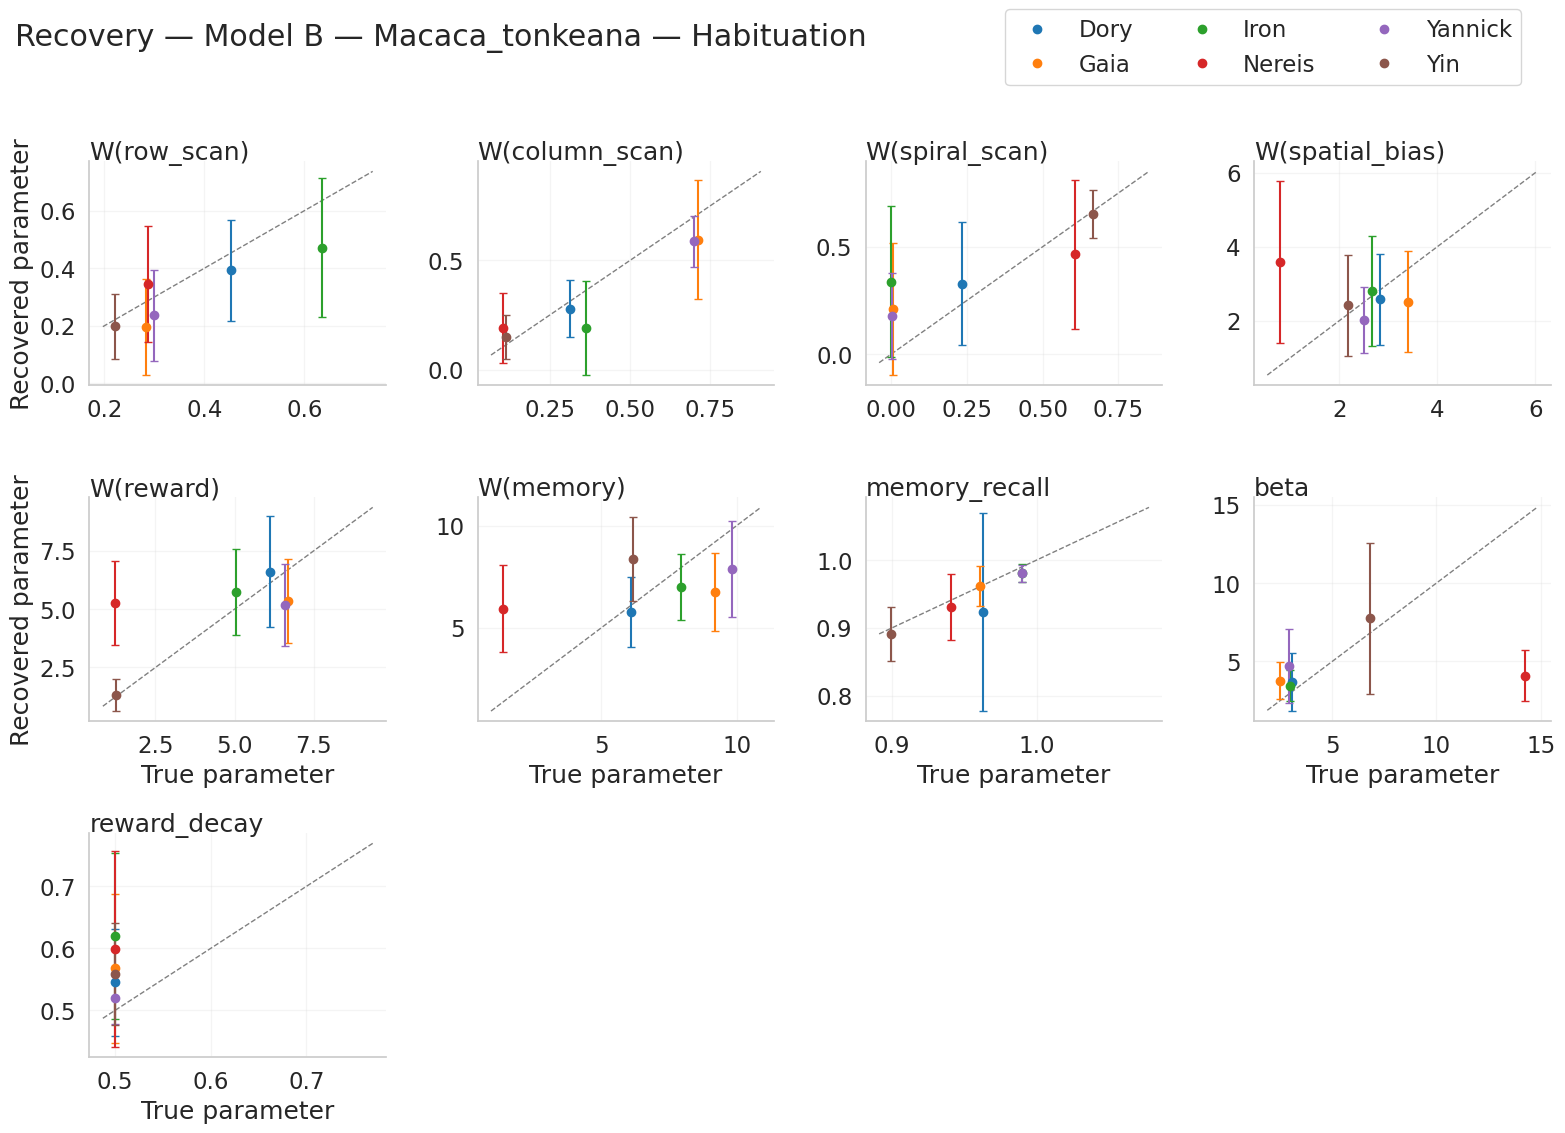

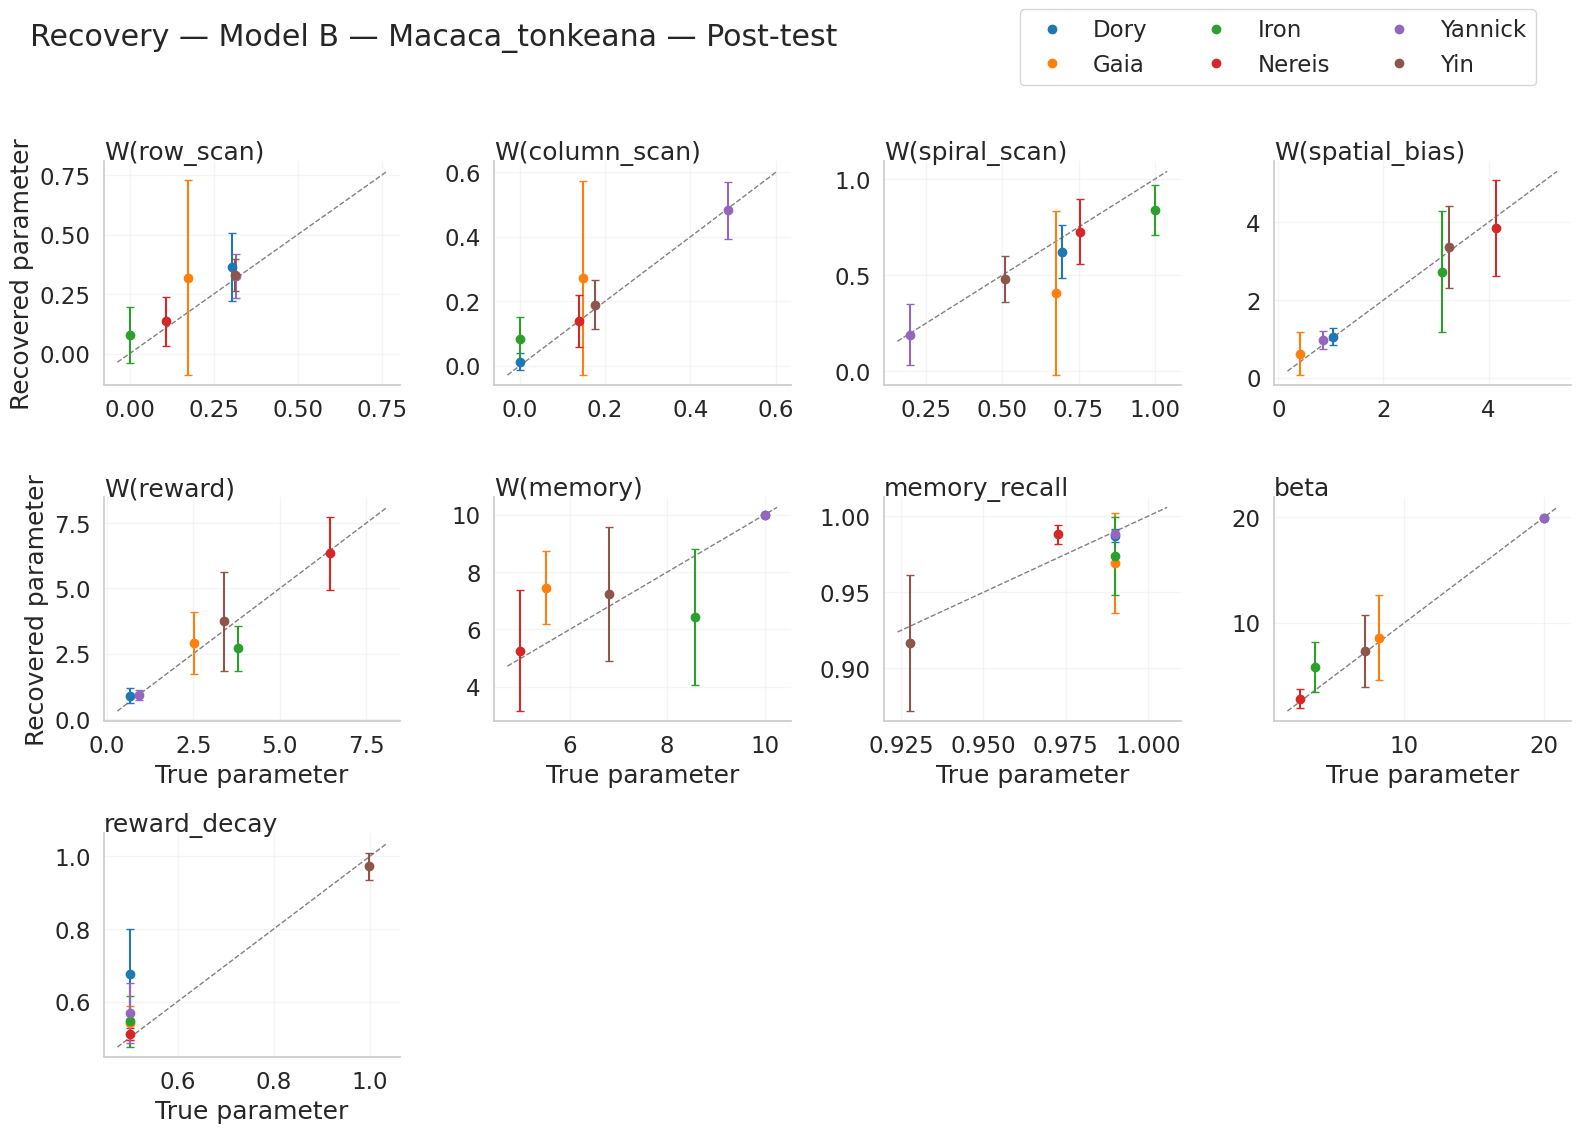

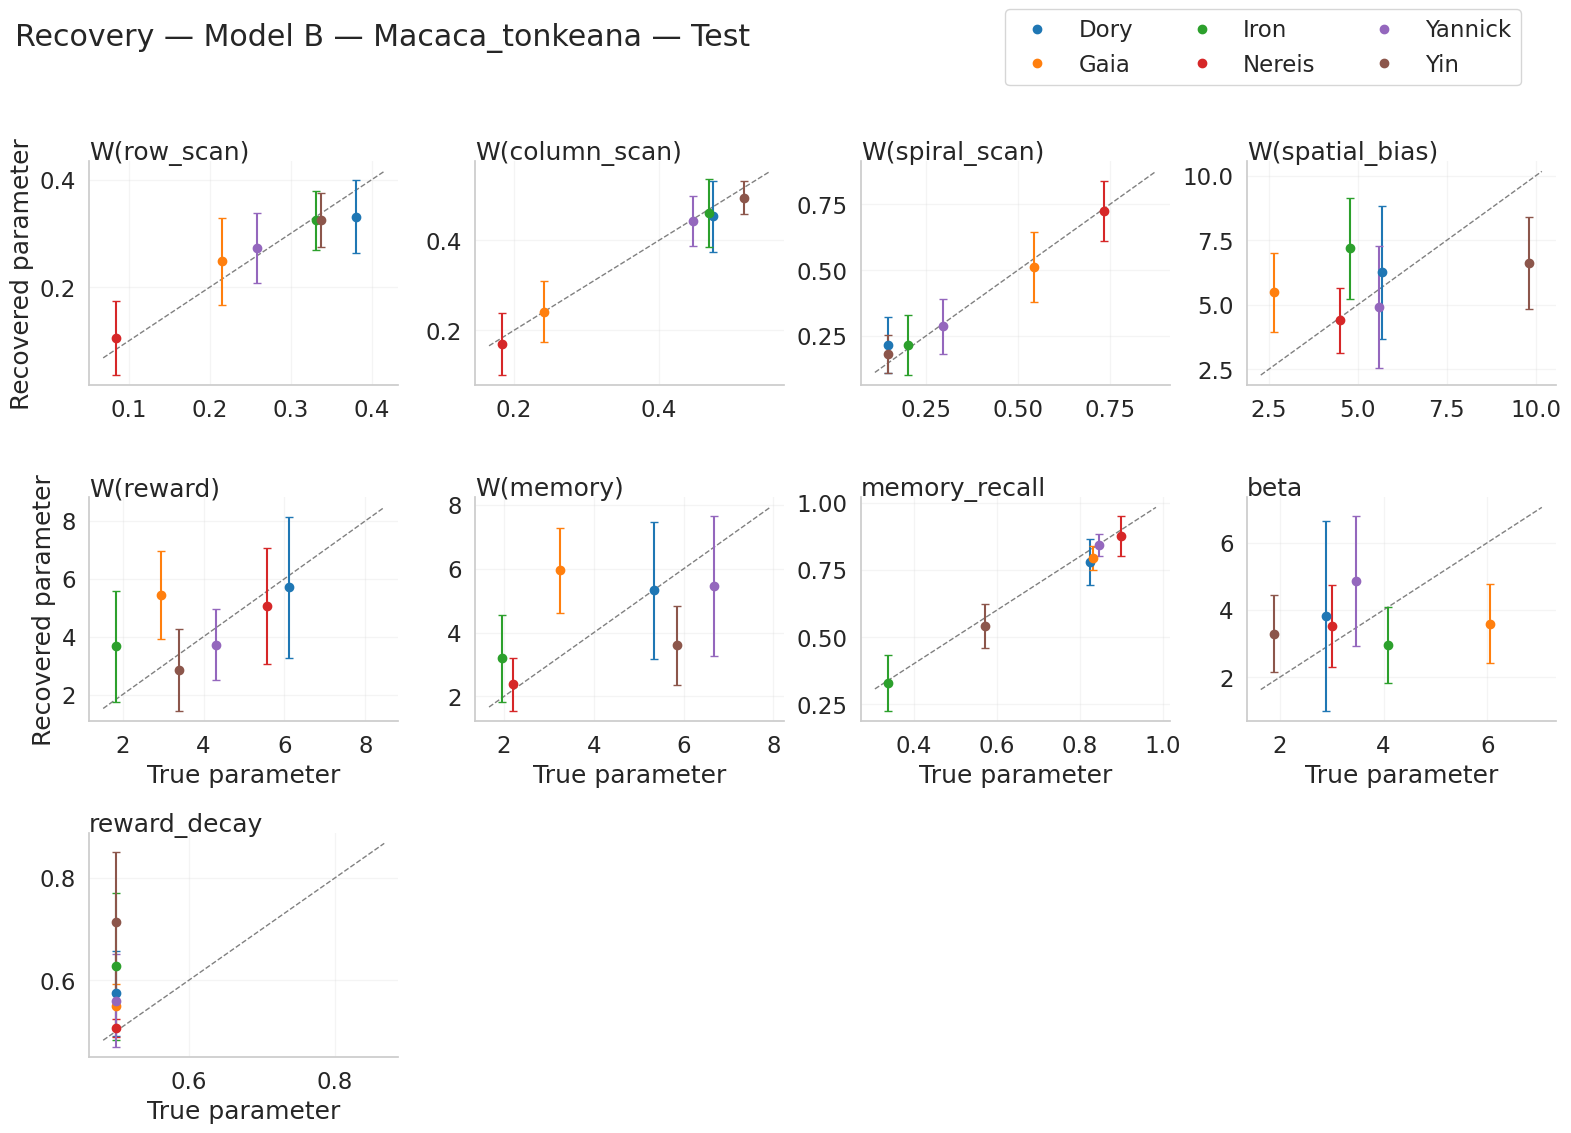

In [193]:
base_params = [
    "W(row_scan)", "W(column_scan)", "W(spiral_scan)",
    "W(spatial_bias)", "W(reward)", "W(memory)",
    "memory_recall", "beta",
]
model_params = {
    "A": base_params,
    "B": base_params + ["reward_decay"],
#     "C": base_params + ["W(reward_availability)"],
}
# plt.rcParams['axes.titley'] = 0.97
# plt.rcParams['axes.titlelocation'] = 'left' 

for model in ["A", "B"]:
    submodel = recovery_df[recovery_df["Model"] == model].copy()

    for species in sorted(submodel["Species"].dropna().unique()):
        for phase in sorted(
            submodel.loc[submodel["Species"] == species, "Phase"]
            .dropna().unique()
        ):
            sub = submodel[
                (submodel["Species"] == species)
                & (submodel["Phase"] == phase)
            ].copy()

            params = [
                p for p in model_params[model]
                if p in sub.columns and f"{p} - sim" in sub.columns
            ]

            ncols = 4
            nrows = int(np.ceil(len(params) / ncols))
            fig, axes = plt.subplots(
                nrows, ncols, figsize=(16, 4*nrows), squeeze=False
            )
            axes = axes.flatten()

            subjects = sorted(sub["Subject"].dropna().unique())
            cmap = plt.get_cmap("tab10")
            subject_colors = {
                s: cmap(i % 10) for i, s in enumerate(subjects)
            }
            
            ax_i = 0
            for ax, par in zip(axes, params):
                rec = f"{par} - sim"
                summary = (
                    sub.groupby("Subject")
                    .agg(
                        true_value=(par, "first"),
                        recovered_mean=(rec, "mean"),
                        recovered_sd=(rec, "std"),
                    )
                    .reset_index()
                )

                valid = pd.concat([
                    summary["true_value"],
                    summary["recovered_mean"] + summary["recovered_sd"]
                ]).dropna()

                if len(valid):
                    lo, hi = valid.min(), valid.max()
                    pad = 0.05 if np.isclose(lo, hi) else 0.05*(hi-lo)
                    if np.isclose(lo, hi) and lo != 0:
                        pad = abs(lo)*0.05
                    ax.plot(
                        [lo-pad, hi+pad], [lo-pad, hi+pad],
                        "--", color="gray", linewidth=1
                    )

                for _, row in summary.iterrows():
                    if pd.isna(row["true_value"]):
                        continue
                    ax.errorbar(
                        row["true_value"],
                        row["recovered_mean"],
                        yerr=row["recovered_sd"],
                        fmt="o", markersize=6, capsize=3,
                        color=subject_colors[row["Subject"]]
                    )

                ax.set_xlabel("True parameter")
                ax.set_ylabel("Recovered parameter")
                ax.set_title(par)
                ax.grid(alpha=0.2)
                if ax_i <=3 :
                    ax.set_xlabel("")

                if ax_i not in [0,4]:
                    ax.set_ylabel("")

                ax.spines.top.set_visible(False)
                ax.spines.right.set_visible(False)
                ax_i = ax_i + 1                

            for ax in axes[len(params):]:
                ax.axis("off")

            handles = [
                Line2D(
                    [0], [0], marker="o", linestyle="",
                    color=subject_colors[s], label=s, markersize=6
                )
                for s in subjects
            ]
            if handles:
#                 if 'tonkean' in species and model == 'A':
                    
                if 'mulatta' in species and model == 'B' :
                    fig.legend(
                        handles=handles, loc="lower center",
                        ncol=min(3, len(handles)),
                        bbox_to_anchor=(0.5, 0.2)
                    )
                else:
                    fig.legend(
                        handles=handles, loc="upper center",
                        ncol=min(3, len(handles)),
                        bbox_to_anchor=(0.8, 1.0)
                    )
                    
                    
            fig.suptitle(
                f"Recovery — Model {model} — {species} — {phase}",x=0.02,y=0.98,ha="left",va="top"             
            )
            plt.tight_layout(rect=[0, 0.04, 1, 0.95])
            fig.savefig(fig_dir+"recovery_plots_"+model+"_"+species+"_"+phase+".png")
#             plt.show()